<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%EC%8A%A4%ED%94%84%EB%A6%B0%ED%8A%B8%EB%AF%B8%EC%85%98%5D14_%EB%B6%84%EC%84%9D%EC%8B%A4%EC%8A%B5_4%ED%8C%80_%EA%B9%80%EC%86%8C%EC%97%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**보고서 : https://www.canva.com/design/DAGfDIer7Ic/tFGr0f6s84MonIzmAsUdzA/view?utm_content=DAGfDIer7Ic&utm_campaign=designshare&utm_medium=link2&utm_source=uniquelinks&utlId=ha5507d6b04**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# 1.EDA

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

## 데이터 기본 구조 확인

In [ ]:
# 데이터 쉐입 살펴보기
print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)

train_df.head()

Train Data Shape: (10886, 12)
Test Data Shape: (6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
print(train_df.info())
print(train_df.isnull().sum())
print(train_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64
0


1. 결측치 없음 → 모든 컬럼에 10886개의 데이터가 있음
2. datetime 컬럼이 object 타입 → datetime으로 변환 필요
3. 중복값없음

In [ ]:
train_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
# 실제 대여량 평균 계산
mean_count = train_df["count"].mean()
print(f"한시간당 평균 대여량: {mean_count:.2f}")

# 실제 대여량 중앙값 계산
median_count = train_df["count"].median()
print(f"한시간당 대여량 중앙값: {median_count:.2f}")

한시간당 평균 대여량: 191.57
한시간당 대여량 중앙값: 145.00


## 자전거 대여수(count) 분포 확인

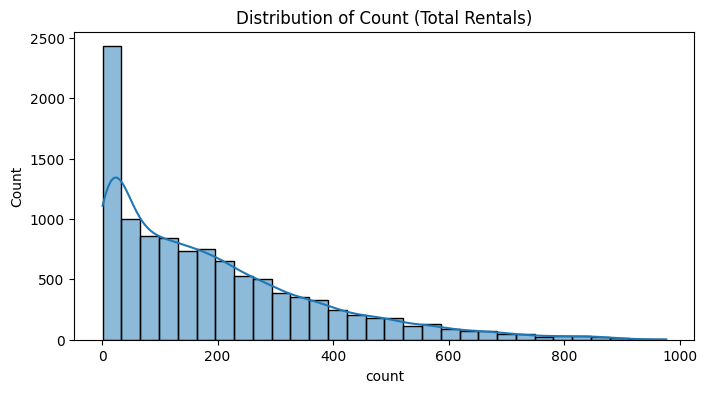

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['count'], bins=30, kde=True)
plt.title("Distribution of Count (Total Rentals)")
plt.show()

- 오른쪽으로 치우친 분포
- 로그 변환이 필요할 가능성 높음

## datetime 변환 및 시간별 대여량 확인

In [ ]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek

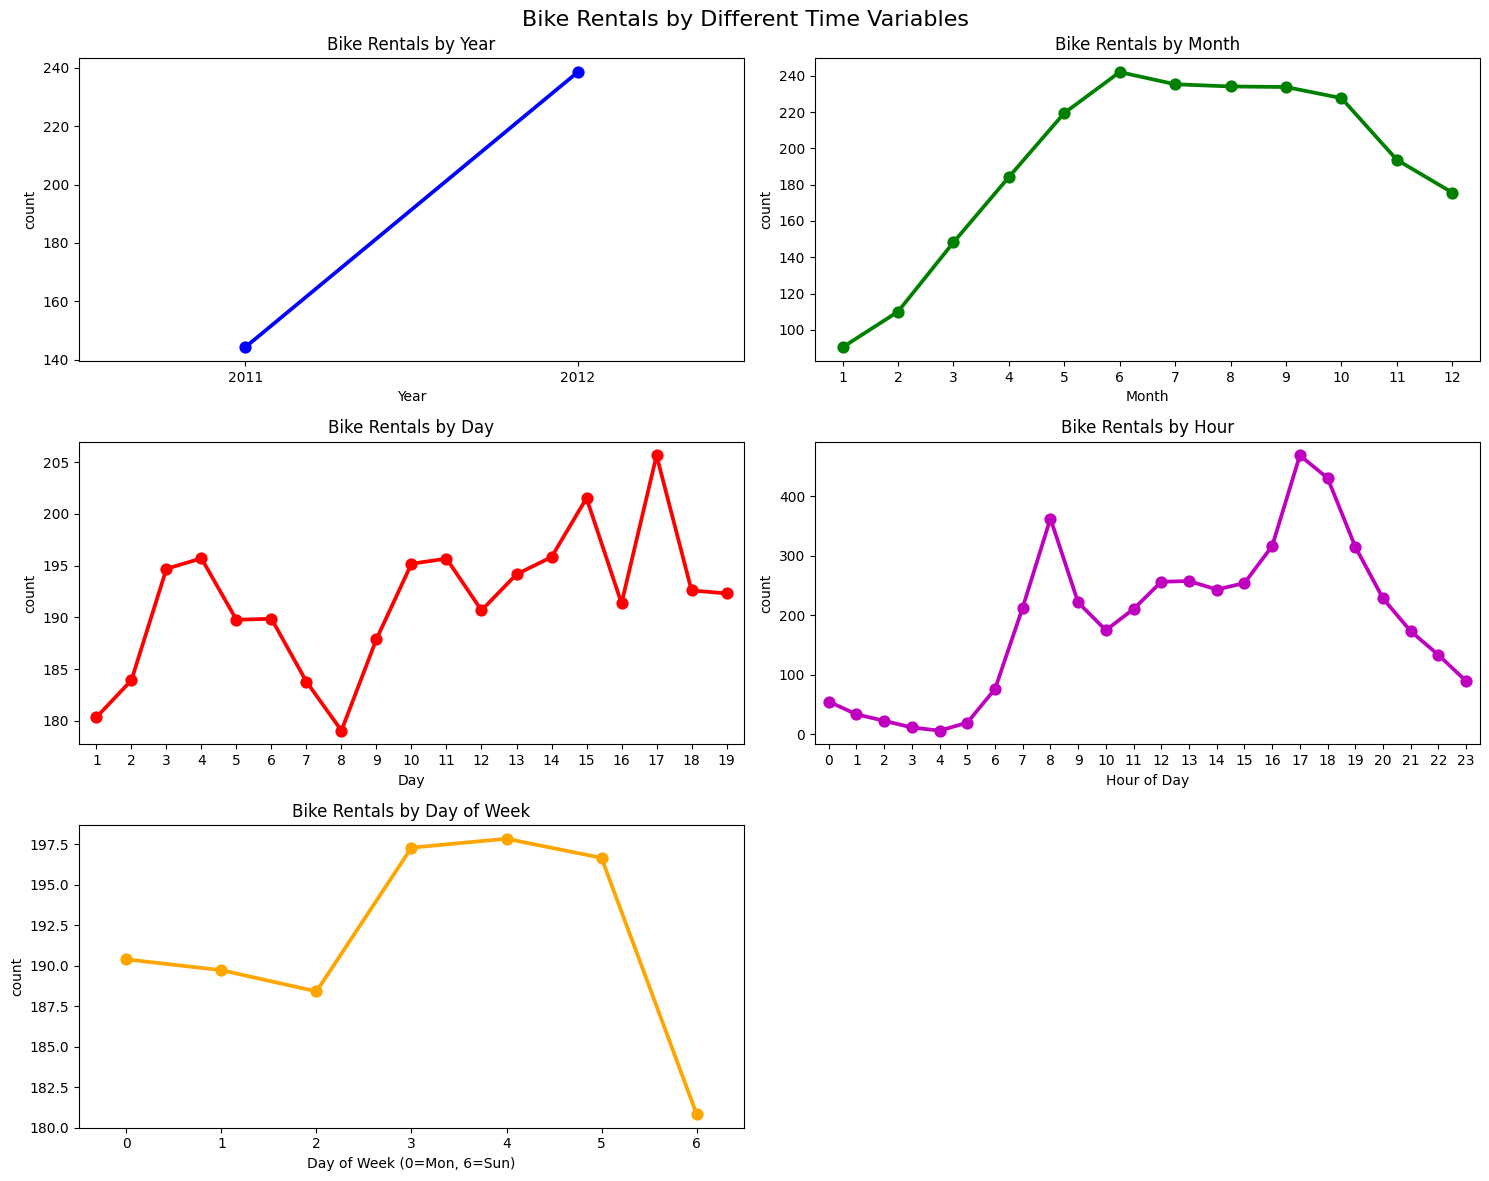

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle("Bike Rentals by Different Time Variables", fontsize=16)

# 연도별 대여량
sns.pointplot(data=train_df, x="year", y="count", errorbar=None, ax=axes[0, 0], color="b")
axes[0, 0].set_title("Bike Rentals by Year")
axes[0, 0].set_xlabel("Year")

# 월별 대여량
sns.pointplot(data=train_df, x="month", y="count", errorbar=None, ax=axes[0, 1], color="g")
axes[0, 1].set_title("Bike Rentals by Month")
axes[0, 1].set_xlabel("Month")

# 일별 대여량
sns.pointplot(data=train_df, x="day", y="count", errorbar=None, ax=axes[1, 0], color="r")
axes[1, 0].set_title("Bike Rentals by Day")
axes[1, 0].set_xlabel("Day")

# 시간별 대여량
sns.pointplot(data=train_df, x="hour", y="count", errorbar=None, ax=axes[1, 1], color="m")
axes[1, 1].set_title("Bike Rentals by Hour")
axes[1, 1].set_xlabel("Hour of Day")

# 요일별 대여량
sns.pointplot(data=train_df, x="dayofweek", y="count", errorbar=None, ax=axes[2, 0], color="orange")
axes[2, 0].set_title("Bike Rentals by Day of Week")
axes[2, 0].set_xlabel("Day of Week (0=Mon, 6=Sun)")

axes[2, 1].axis("off") # 빈 서브플롯 제거

plt.tight_layout()
plt.show()

## datetime외 각 변수와 대여량과의 관계 시각화

- 범주형 변수

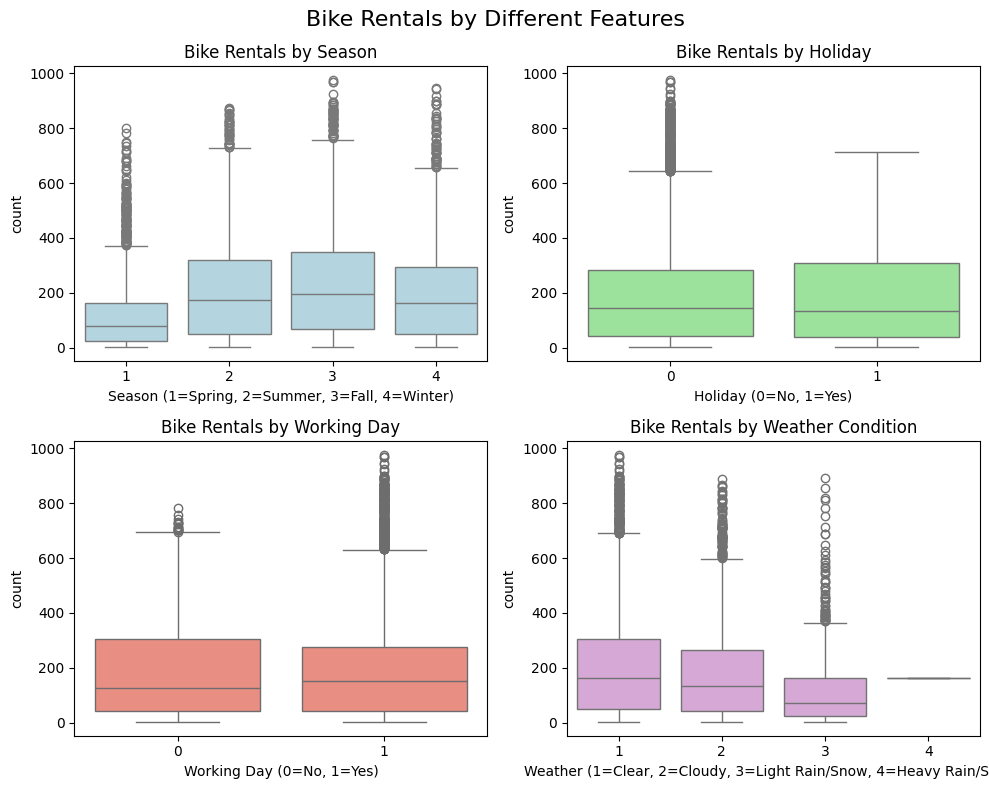

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Bike Rentals by Different Features", fontsize=16)

# 계절
sns.boxplot(data=train_df, x="season", y="count", ax=axes[0, 0], color="lightblue")
axes[0, 0].set_title("Bike Rentals by Season")
axes[0, 0].set_xlabel("Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)")

# 휴일
sns.boxplot(data=train_df, x="holiday", y="count", ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_title("Bike Rentals by Holiday")
axes[0, 1].set_xlabel("Holiday (0=No, 1=Yes)")

# 주중
sns.boxplot(data=train_df, x="workingday", y="count", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Bike Rentals by Working Day")
axes[1, 0].set_xlabel("Working Day (0=No, 1=Yes)")

# 날씨 상황
sns.boxplot(data=train_df, x="weather", y="count", ax=axes[1, 1], color="plum")
axes[1, 1].set_title("Bike Rentals by Weather Condition")
axes[1, 1].set_xlabel("Weather (1=Clear, 2=Cloudy, 3=Light Rain/Snow, 4=Heavy Rain/Snow)")

plt.tight_layout()
plt.show()

- 수치형 변수

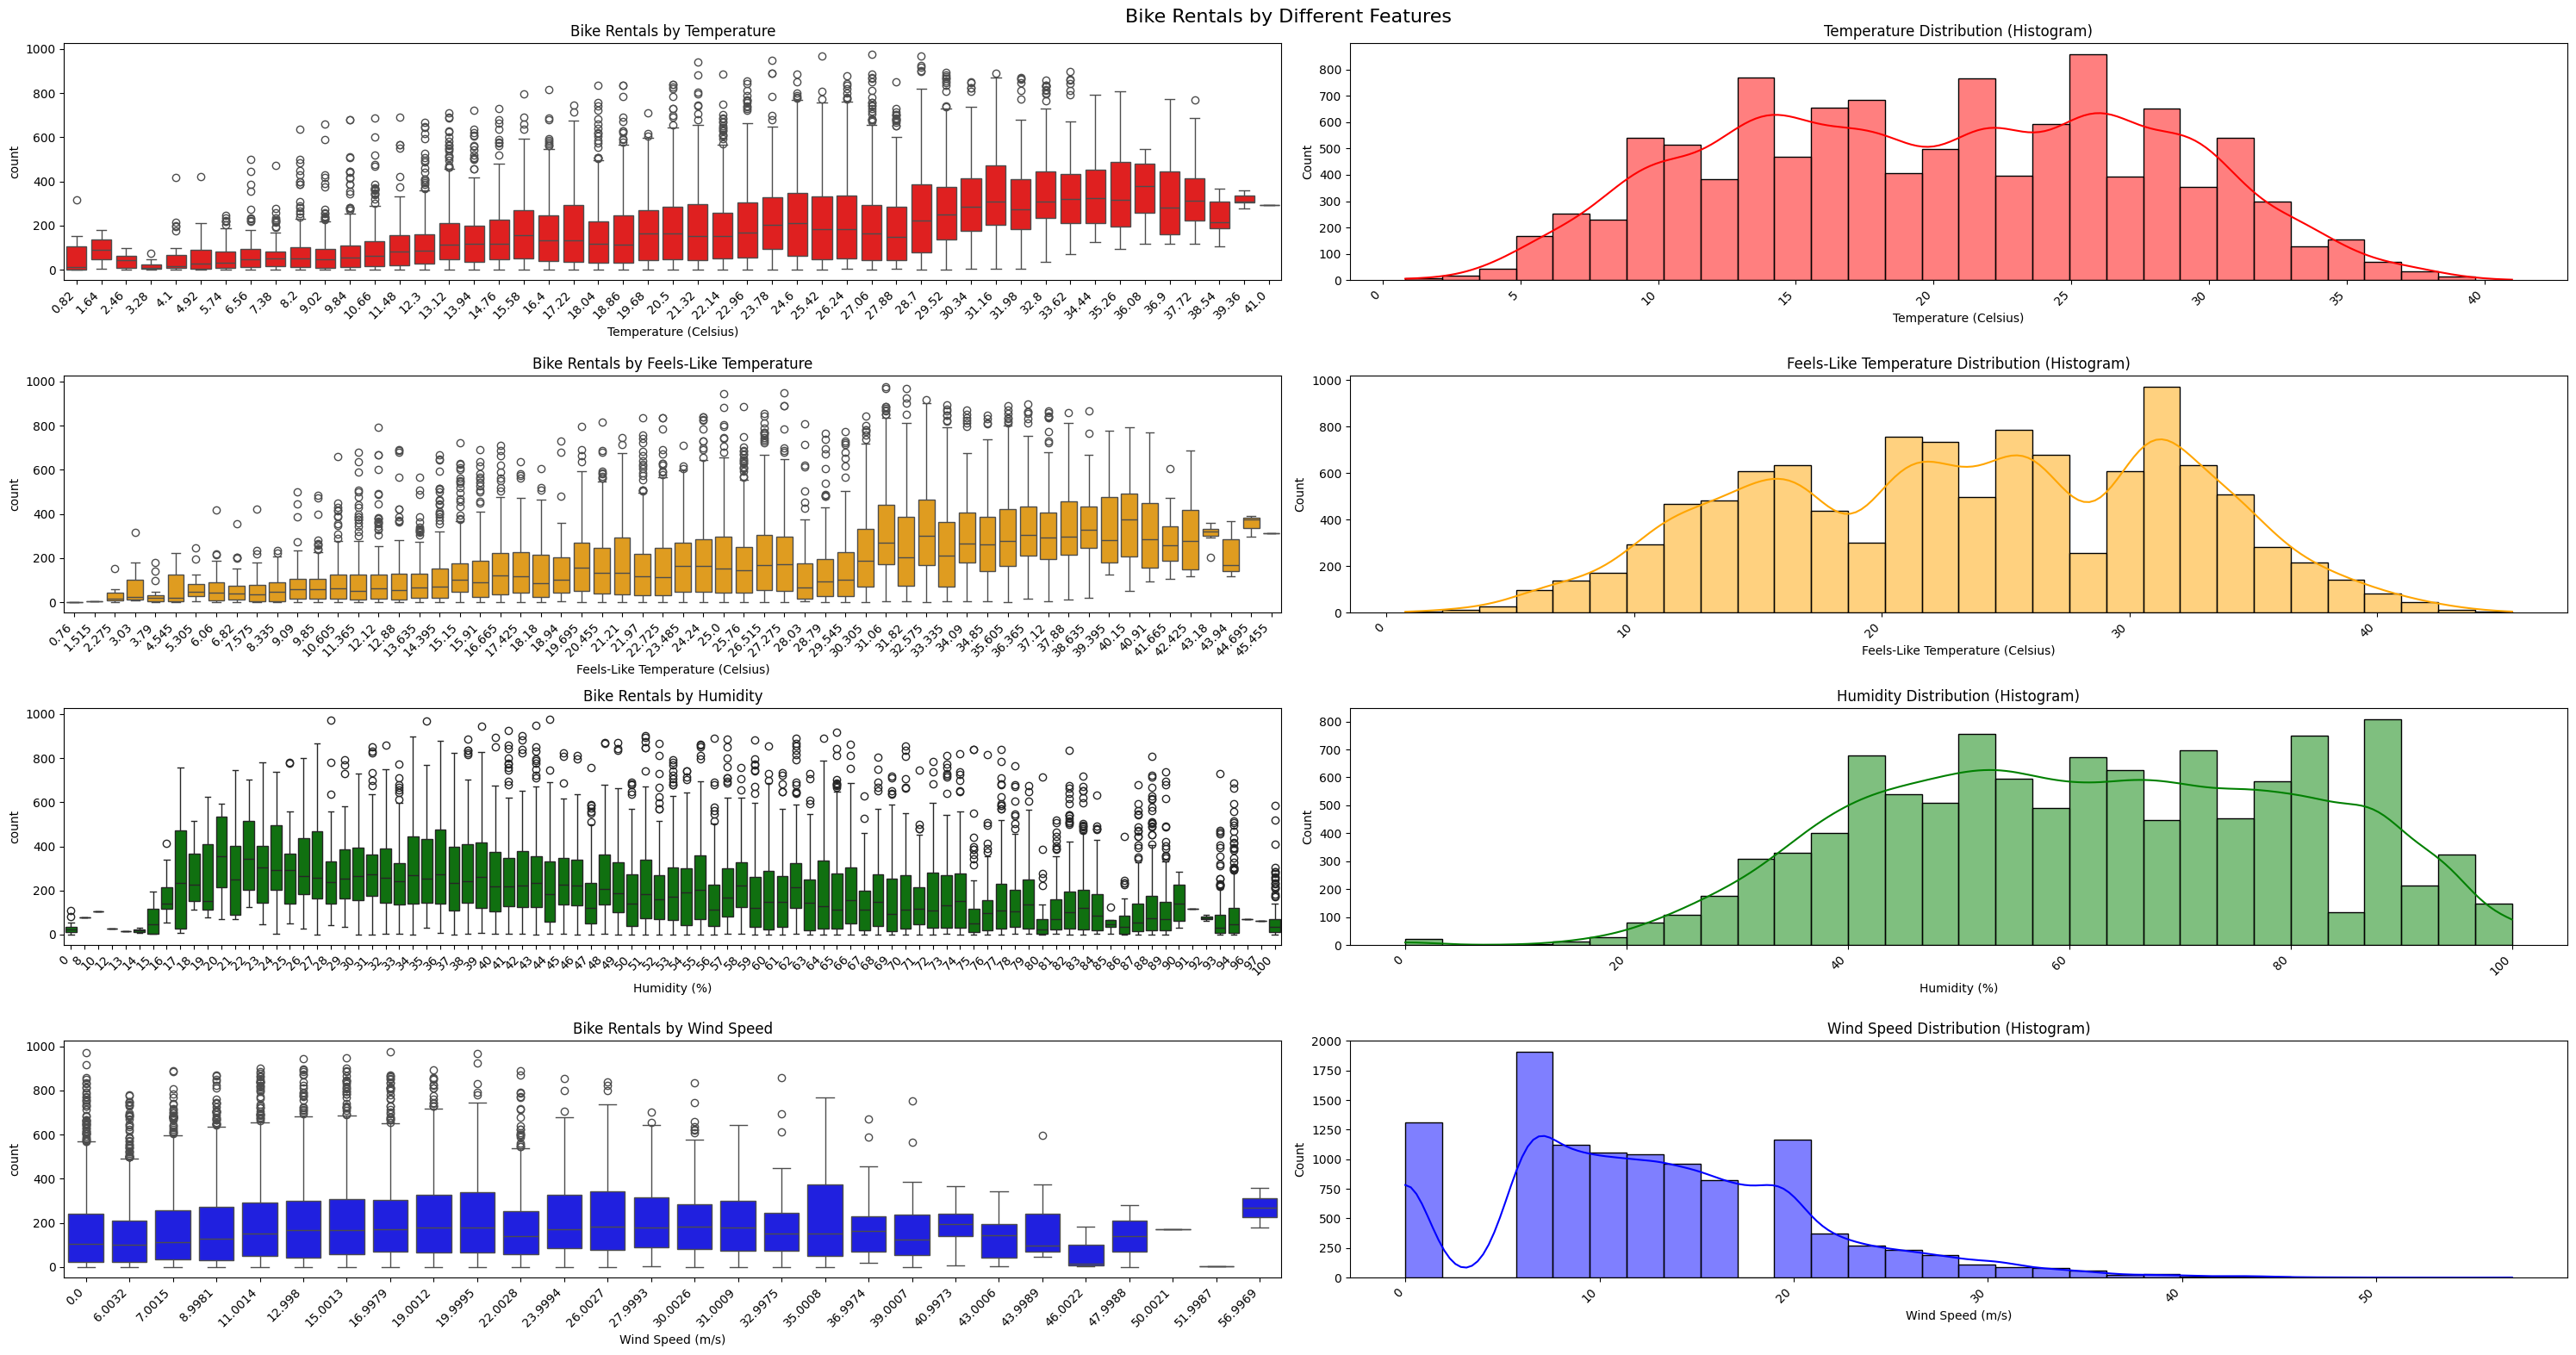

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(30, 16))
fig.suptitle("Bike Rentals by Different Features", fontsize=16)

# 실측 온도 (섭씨) - 박스플롯과 히스토그램
sns.boxplot(data=train_df, x="temp", y="count", ax=axes[0, 0], color="red")
axes[0, 0].set_title("Bike Rentals by Temperature")
axes[0, 0].set_xlabel("Temperature (Celsius)")
sns.histplot(data=train_df, x="temp", bins=30, kde=True, ax=axes[0, 1], color="red")
axes[0, 1].set_title("Temperature Distribution (Histogram)")
axes[0, 1].set_xlabel("Temperature (Celsius)")

# 체감 온도 (섭씨) - 박스플롯과 히스토그램
sns.boxplot(data=train_df, x="atemp", y="count", ax=axes[1, 0], color="orange")
axes[1, 0].set_title("Bike Rentals by Feels-Like Temperature")
axes[1, 0].set_xlabel("Feels-Like Temperature (Celsius)")
sns.histplot(data=train_df, x="atemp", bins=30, kde=True, ax=axes[1, 1], color="orange")
axes[1, 1].set_title("Feels-Like Temperature Distribution (Histogram)")
axes[1, 1].set_xlabel("Feels-Like Temperature (Celsius)")

# 습도 - 박스플롯과 히스토그램
sns.boxplot(data=train_df, x="humidity", y="count", ax=axes[2, 0], color="green")
axes[2, 0].set_title("Bike Rentals by Humidity")
axes[2, 0].set_xlabel("Humidity (%)")
sns.histplot(data=train_df, x="humidity", bins=30, kde=True, ax=axes[2, 1], color="green")
axes[2, 1].set_title("Humidity Distribution (Histogram)")
axes[2, 1].set_xlabel("Humidity (%)")

# 풍속 - 박스플롯과 히스토그램
sns.boxplot(data=train_df, x="windspeed", y="count", ax=axes[3, 0], color="blue")
axes[3, 0].set_title("Bike Rentals by Wind Speed")
axes[3, 0].set_xlabel("Wind Speed (m/s)")
sns.histplot(data=train_df, x="windspeed", bins=30, kde=True, ax=axes[3, 1], color="blue")
axes[3, 1].set_title("Wind Speed Distribution (Histogram)")
axes[3, 1].set_xlabel("Wind Speed (m/s)")

# X축 레이블 회전
for ax in axes.flatten():
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=10)

plt.tight_layout()
plt.show()


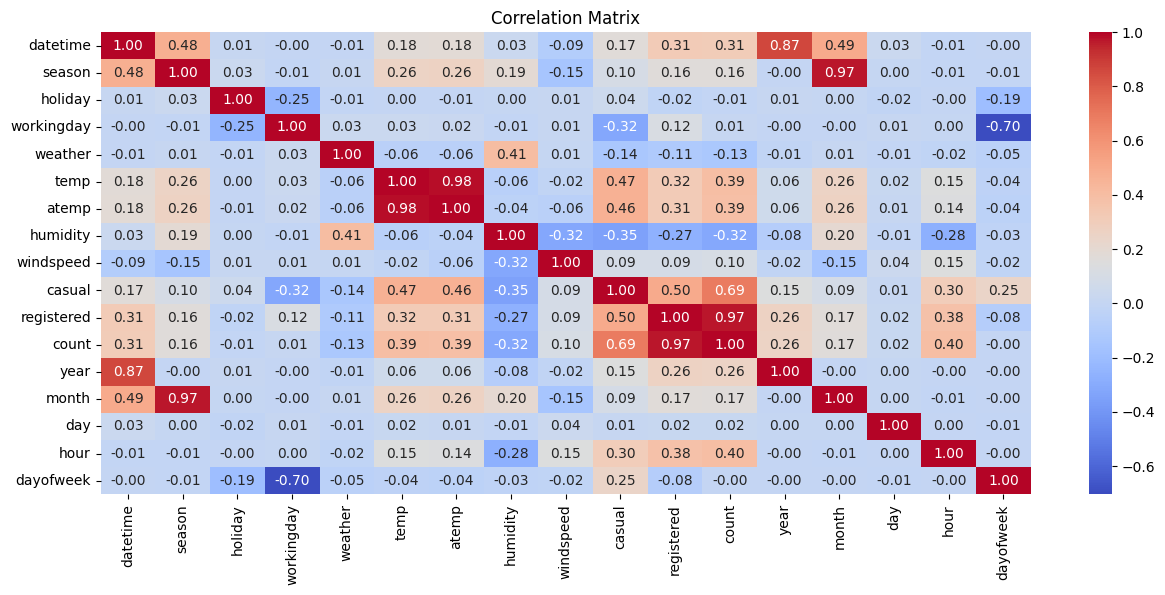

In [ ]:
# 모든 변수 간 상관관계 분석
corr_matrix = train_df.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

- casual + registered = count
- temp와 atemp가 상당히 높음
  - 둘 중 하나 무조건 삭제

# **2.선형 회귀 모델 분석**

# ⭐ Baseline 모델 생성

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
train_df.drop(columns=['casual', 'registered'], inplace=True)

In [ ]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

def rmsle_log_transformed(y_true, y_pred):
    """로그 변환된 상태에서 RMSLE 계산"""
    return np.sqrt(mean_squared_error(y_true, y_pred))  # 로그 변환 다시 하지 않음!

def rmsle(y_true, y_pred):
    y_true = np.maximum(y_true, 0)  # 음수 방지
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))


In [ ]:
# Baseline 모델 설정
X_baseline = train_df.drop(columns=["count", "datetime"])
y_baseline = train_df["count"]

# 데이터 분할 (Train/Test Split)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, test_size=0.3, random_state=5
)


### 🔎 성능 평가

In [ ]:
# 선형 회귀 모델 학습
baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train_base)

# 예측 수행
y_train_pred_base = baseline_model.predict(X_train_base)
y_test_pred_base = baseline_model.predict(X_test_base)

# 음수 예측값을 0으로 변환 (음수 방지)
y_train_pred_base = np.maximum(y_train_pred_base, 0)
y_test_pred_base = np.maximum(y_test_pred_base, 0)

# RMSE 계산
rmse_train_base = np.sqrt(mean_squared_error(y_train_base, y_train_pred_base))
rmse_test_base = np.sqrt(mean_squared_error(y_test_base, y_test_pred_base))

# RMSLE 계산
rmsle_train_base = rmsle(y_train_base, y_train_pred_base)
rmsle_test_base = rmsle(y_test_base, y_test_pred_base)

# 성능 평가 결과 출력 (Baseline 모델)
print("🚀 [성능 평가] Baseline 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_base:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_base:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_base:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_base:.4f}")

🚀 [성능 평가] Baseline 모델
✅ RMSE (훈련 데이터): 156.1296
✅ RMSE (테스트 데이터): 154.1943
✅ RMSLE (훈련 데이터): 1.4272
✅ RMSLE (테스트 데이터): 1.4317


- 선형 회귀 모델에서의 회귀 계수 확인

In [ ]:
# 선형 회귀 모델에서의 회귀 계수 확인
coef = baseline_model.coef_

# X_train_base.columns로 피처 수가 맞지 않을 수 있기 때문에
# X_train_base의 피처 변환을 반영한 컬럼명으로 수정
feature_importance = pd.DataFrame(coef, X_train_base.columns, columns=["Coefficient"])

feature_importance


,Coefficient
season,23.529427
holiday,-6.383434
workingday,0.042788
weather,8.492004
temp,1.205075
atemp,6.189814
humidity,-3.083961
windspeed,0.828438


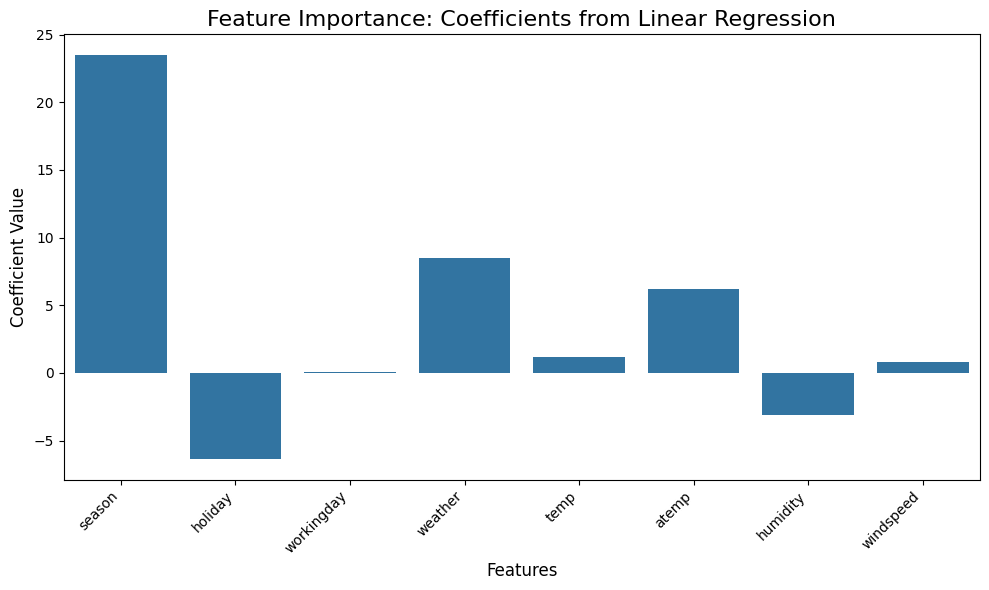

In [ ]:
# 선형 회귀 모델에서의 회귀 계수 확인
coef = baseline_model.coef_

# X_train_base.columns로 피처 수가 맞지 않을 수 있기 때문에
# X_train_base의 피처 변환을 반영한 컬럼명으로 수정
feature_importance = pd.DataFrame(coef, X_train_base.columns, columns=["Coefficient"])

feature_importance
# 회귀 계수 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.index, y=feature_importance["Coefficient"])
plt.title("Feature Importance: Coefficients from Linear Regression", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.xticks(rotation=45, ha='right')

# 그래프 출력
plt.tight_layout()
plt.show()


# ⭐Feature Engineering 적용

## 전처리

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
train_df.drop(columns=['casual', 'registered'], inplace=True)

In [ ]:
# 시계열 정렬 (날짜 기준)
train_df["datetime"] = pd.to_datetime(train_df["datetime"])
test_df["datetime"] = pd.to_datetime(test_df["datetime"])

test_df = test_df.sort_values(by="datetime").reset_index(drop=True)
train_df = train_df.sort_values(by="datetime").reset_index(drop=True)

In [ ]:
# datetime을 datetime 형식으로 변환 및 새로운 컬럼 생성
for df in [train_df, test_df]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek

In [ ]:
# datetime 컬럼 삭제
train_df.drop(columns=['datetime'], inplace=True)
test_df.drop(columns=['datetime'], inplace=True)

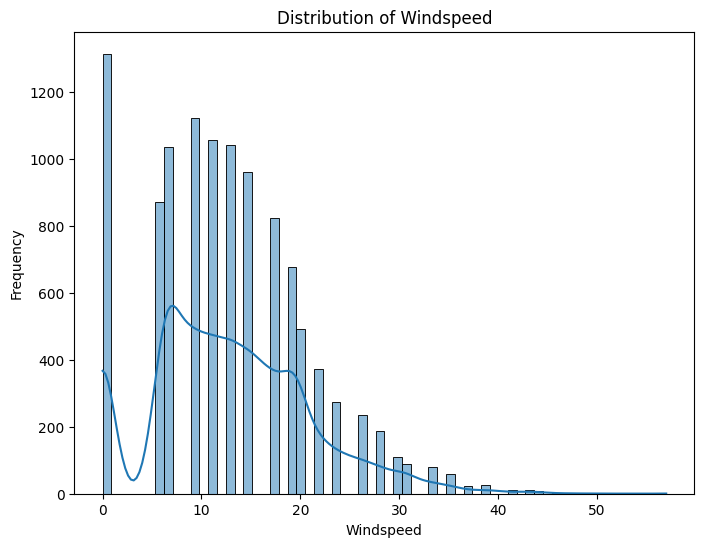

In [ ]:
# windspeed plot
plt.figure(figsize=(8, 6))
sns.histplot(train_df['windspeed'], kde=True)
plt.title('Distribution of Windspeed')
plt.xlabel('Windspeed')
plt.ylabel('Frequency')
plt.show()


In [ ]:
train_df["temp_diff"] = train_df["atemp"] - train_df["temp"]
train_df["temp_ratio"] = train_df["atemp"] / train_df["temp"]
train_df["weighted_temp"] = 0.7 * train_df["temp"] + 0.3 * train_df["atemp"]
train_df["temp_std_diff"] = (train_df["atemp"] - train_df["temp"]) / train_df["temp"].std()

In [ ]:
test_df["temp_diff"] = test_df["atemp"] - test_df["temp"]
test_df["temp_ratio"] = test_df["atemp"] / test_df["temp"]
test_df["weighted_temp"] = 0.7 * test_df["temp"] + 0.3 * test_df["atemp"]
test_df["temp_std_diff"] = (test_df["atemp"] - test_df["temp"]) / test_df["temp"].std()

## 풍속 == 0 랜덤 포레스트이용하여 예측

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# windspeed == 0인 데이터와 아닌 데이터 분리
train_dfWind0 = train_df[train_df["windspeed"]==0].copy()
train_dfWindNot0 = train_df[train_df["windspeed"]!=0]
rfModel_wind = RandomForestRegressor()

windColumns = ["season","weather","humidity","month","temp","year","atemp"]
rfModel_wind.fit(train_dfWindNot0[windColumns], train_dfWindNot0["windspeed"])

wind0Values = rfModel_wind.predict(X= train_dfWind0[windColumns])
train_dfWind0["windspeed"] = wind0Values
train_df = pd.concat([train_dfWindNot0, train_dfWind0])

In [ ]:
# windspeed == 0인 데이터와 아닌 데이터 분리
test_dfWind0 = test_df[test_df["windspeed"] == 0].copy()
test_dfWindNot0 = test_df[test_df["windspeed"] != 0]

# windspeed 예측할 피처 선택
windColumns = ["season", "weather", "humidity", "month", "temp", "year", "atemp"]

# 기존 훈련된 모델을 사용해야 함! (새로운 모델을 훈련하면 안 됨)
wind0Values = rfModel_wind.predict(X=test_dfWind0[windColumns])

# 예측한 windspeed 값 적용
test_dfWind0["windspeed"] = wind0Values

# 원래 windspeed!=0인 데이터와 합치기
test_df = pd.concat([test_dfWindNot0, test_dfWind0])


In [ ]:
scaler = StandardScaler()

###########
train_df[['temp_diff', 'temp_ratio', 'weighted_temp', 'temp_std_diff', 'humidity']] = scaler.fit_transform(train_df[['temp_diff', 'temp_ratio', 'weighted_temp', 'temp_std_diff', 'humidity']])
train_df['windspeed'] = MinMaxScaler().fit_transform(np.log1p(train_df[['windspeed']]))

############
test_df[['temp_diff', 'temp_ratio', 'weighted_temp', 'temp_std_diff', 'humidity']] = scaler.fit_transform(test_df[['temp_diff', 'temp_ratio', 'weighted_temp', 'temp_std_diff', 'humidity']])
test_df['windspeed'] = MinMaxScaler().fit_transform(np.log1p(test_df[['windspeed']]))

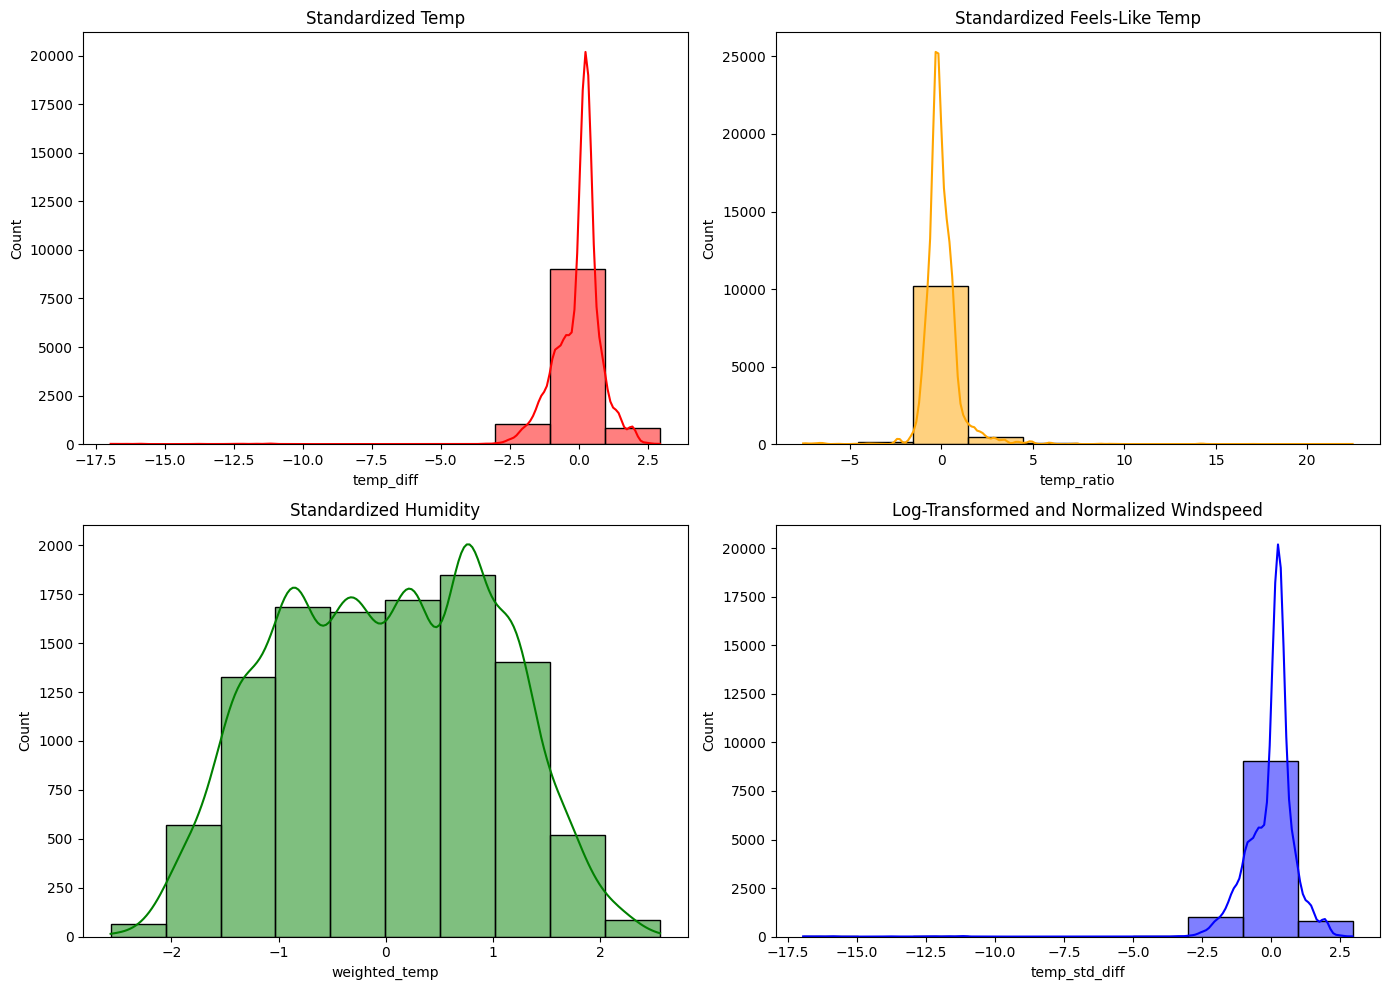

In [ ]:
# 데이터 전처리 후 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train_df['temp_diff'], kde=True, color='red', bins=10, ax=axes[0, 0]).set_title('Standardized Temp')
sns.histplot(train_df['temp_ratio'], kde=True, color='orange',  bins=10, ax=axes[0, 1]).set_title('Standardized Feels-Like Temp')
sns.histplot(train_df['weighted_temp'], kde=True, color='green', bins=10,  ax=axes[1, 0]).set_title('Standardized Humidity')
sns.histplot(train_df['temp_std_diff'], kde=True, color='blue', bins=10, ax=axes[1, 1]).set_title('Log-Transformed and Normalized Windspeed')

# 레이아웃 조정
plt.tight_layout()
plt.show()

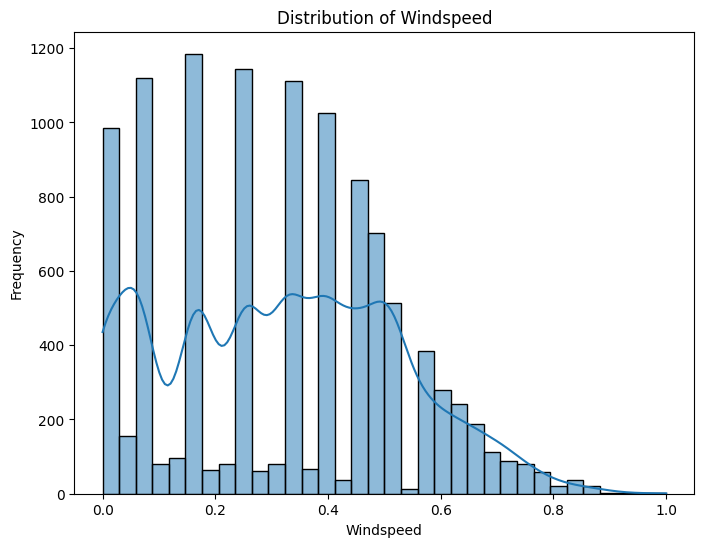

In [ ]:
# windspeed plot
plt.figure(figsize=(8, 6))
sns.histplot(train_df['windspeed'], kde=True)
plt.title('Distribution of Windspeed')
plt.xlabel('Windspeed')
plt.ylabel('Frequency')
plt.show()


- 사인/코사인 변환 (주기성 반영)

In [ ]:
for df in [train_df, test_df]:
    # Hour 변환 (0~23)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Month 변환 (1~12)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Day of the Week 변환 (0~6)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

train_df.drop(columns=["hour","month","dayofweek"], inplace=True)
test_df.drop(columns=["hour","month","dayofweek"], inplace=True)

- 범주형 변수 원-핫 인코딩

In [ ]:
# 범주형 변수 원-핫 인코딩
categorical_features = ["season", "holiday", "workingday", "weather", 'year']
train_df = pd.get_dummies(train_df, columns=categorical_features, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_features, drop_first=True)

- 로그 변환 적용

In [ ]:
# 로그 변환 적용 (대여량 count)
train_df["count"] = np.log1p(train_df["count"])

In [ ]:
train_df['season_2'] = train_df['season_2'].astype(int)
train_df['season_3'] = train_df['season_3'].astype(int)
train_df['season_4'] = train_df['season_4'].astype(int)
train_df['holiday_1'] = train_df['holiday_1'].astype(int)
train_df['workingday_1'] = train_df['workingday_1'].astype(int)
train_df['weather_2'] = train_df['weather_2'].astype(int)
train_df['weather_3'] = train_df['weather_3'].astype(int)
train_df['weather_4'] = train_df['weather_4'].astype(int)
train_df['year_2012'] = train_df['year_2012'].astype(int)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10886 entries, 5 to 10862
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temp           10886 non-null  float64
 1   atemp          10886 non-null  float64
 2   humidity       10886 non-null  float64
 3   windspeed      10886 non-null  float64
 4   count          10886 non-null  float64
 5   temp_diff      10886 non-null  float64
 6   temp_ratio     10886 non-null  float64
 7   weighted_temp  10886 non-null  float64
 8   temp_std_diff  10886 non-null  float64
 9   hour_sin       10886 non-null  float64
 10  hour_cos       10886 non-null  float64
 11  month_sin      10886 non-null  float64
 12  month_cos      10886 non-null  float64
 13  dayofweek_sin  10886 non-null  float64
 14  dayofweek_cos  10886 non-null  float64
 15  season_2       10886 non-null  int64  
 16  season_3       10886 non-null  int64  
 17  season_4       10886 non-null  int64  
 18  holiday_1  

In [ ]:
test_df['season_2'] = test_df['season_2'].astype(int)
test_df['season_3'] = test_df['season_3'].astype(int)
test_df['season_4'] = test_df['season_4'].astype(int)
test_df['holiday_1'] = test_df['holiday_1'].astype(int)
test_df['workingday_1'] = test_df['workingday_1'].astype(int)
test_df['weather_2'] = test_df['weather_2'].astype(int)
test_df['weather_3'] = test_df['weather_3'].astype(int)
test_df['weather_4'] = test_df['weather_4'].astype(int)
test_df['year_2012'] = test_df['year_2012'].astype(int)

test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6493 entries, 0 to 6464
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temp           6493 non-null   float64
 1   atemp          6493 non-null   float64
 2   humidity       6493 non-null   float64
 3   windspeed      6493 non-null   float64
 4   temp_diff      6493 non-null   float64
 5   temp_ratio     6493 non-null   float64
 6   weighted_temp  6493 non-null   float64
 7   temp_std_diff  6493 non-null   float64
 8   hour_sin       6493 non-null   float64
 9   hour_cos       6493 non-null   float64
 10  month_sin      6493 non-null   float64
 11  month_cos      6493 non-null   float64
 12  dayofweek_sin  6493 non-null   float64
 13  dayofweek_cos  6493 non-null   float64
 14  season_2       6493 non-null   int64  
 15  season_3       6493 non-null   int64  
 16  season_4       6493 non-null   int64  
 17  holiday_1      6493 non-null   int64  
 18  workingday_1 

## 모델 학습을 위한 데이터 준비

In [ ]:
X = train_df.drop(columns=["count","atemp", "temp", "weather_4"])
y = train_df["count"]

In [ ]:
X.columns

Index(['humidity', 'windspeed', 'temp_diff', 'temp_ratio', 'weighted_temp',
       'temp_std_diff', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'dayofweek_sin', 'dayofweek_cos', 'season_2', 'season_3', 'season_4',
       'holiday_1', 'workingday_1', 'weather_2', 'weather_3', 'year_2012'],
      dtype='object')

In [ ]:
y

,count
5,0.693147
10,3.610918
11,4.043051
12,4.442651
13,4.553877
...,...
10826,5.451038
10829,5.356586
10846,6.496775
10860,4.890349


In [ ]:
# 데이터 분할 (훈련 데이터와 테스트 데이터)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)

# 분할된 데이터 크기 확인
print(f"훈련 데이터 크기: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"테스트 데이터 크기: X_test: {X_test.shape}, y_test: {y_test.shape}")

훈련 데이터 크기: X_train: (7620, 20), y_train: (7620,)
테스트 데이터 크기: X_test: (3266, 20), y_test: (3266,)


In [ ]:
# 다항 특성 변환
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_poly_scaled, y_train)

y_train_pred = linear_model.predict(X_train_poly_scaled)
y_test_pred = linear_model.predict(X_test_poly_scaled)

### 🔎 중간 성능 평가

In [ ]:
# RMSE 계산 (로그 해제 후 비교)
rmse_train = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred)))
rmse_test = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred)))

rmsle_train = rmsle_log_transformed(y_train, y_train_pred)
rmsle_test = rmsle_log_transformed(y_test, y_test_pred)

# 결과 출력
print("🚀 [중간 성능 평가] Linear Regression")
print(f"✅ RMSE (훈련 데이터): {rmse_train:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test:.4f}")

🚀 [중간 성능 평가] Linear Regression
✅ RMSE (훈련 데이터): 74.0782
✅ RMSE (테스트 데이터): 134.2889
✅ RMSLE (훈련 데이터): 0.3751
✅ RMSLE (테스트 데이터): 0.6290


In [ ]:
# 다항식 변환된 데이터가 numpy 배열이므로, DataFrame으로 변환 필요
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out(), index=X_train.index)

# 회귀 계수 추출
coef = linear_model.coef_

# 회귀 계수 DataFrame 생성
feature_importance = pd.DataFrame(coef, index=X_train_poly_df.columns, columns=["Coefficient"])

print(feature_importance.sort_values(by="Coefficient", ascending=False).head(20))

                                        Coefficient
temp_ratio^2 season_3                      3.023952
temp_ratio month_cos season_4              2.165146
temp_ratio month_cos holiday_1             1.608420
temp_ratio^2                               1.588784
weighted_temp month_cos season_4           1.578806
temp_ratio temp_std_diff month_sin         1.564837
temp_diff temp_ratio month_sin             1.564837
temp_diff temp_ratio month_cos             1.556756
temp_ratio temp_std_diff month_cos         1.556756
weighted_temp month_cos holiday_1          1.421938
weighted_temp dayofweek_sin holiday_1      1.418643
temp_ratio weighted_temp season_4          1.269830
temp_diff temp_ratio weighted_temp         0.851473
temp_ratio weighted_temp temp_std_diff     0.851473
temp_diff^2 season_3                       0.827893
temp_diff temp_std_diff season_3           0.827893
temp_std_diff^2 season_3                   0.827893
windspeed temp_std_diff season_3           0.805188
windspeed te

<Figure size 1200x600 with 0 Axes>

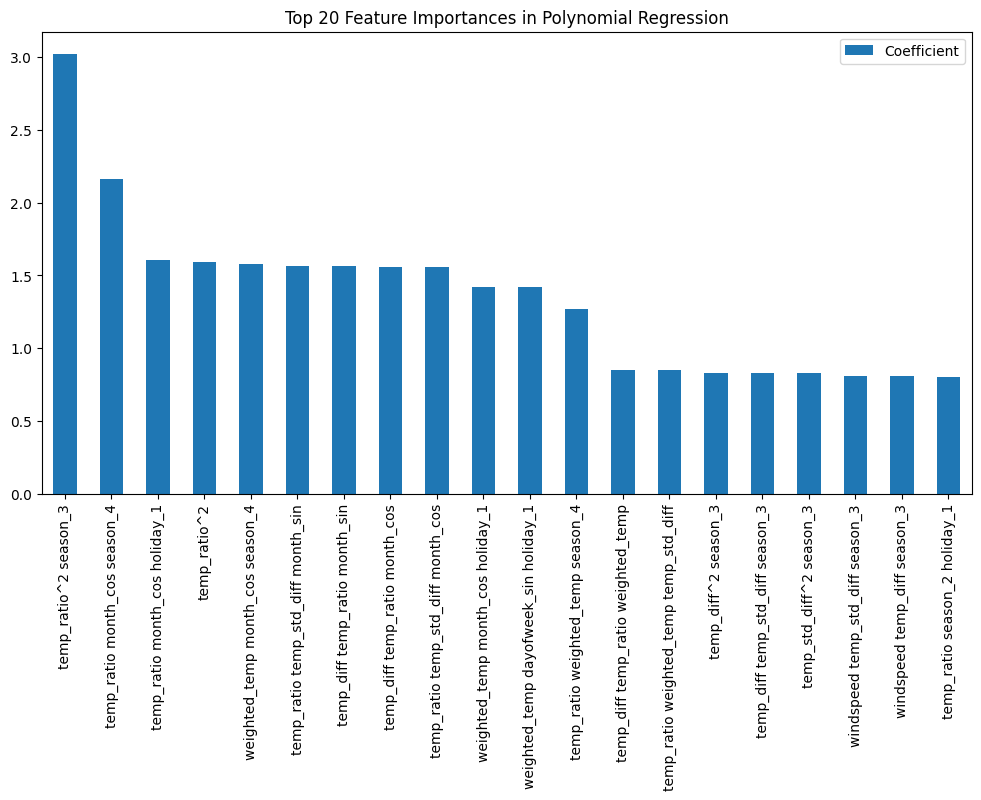

In [ ]:
# 회귀 계수 시각화
plt.figure(figsize=(12, 6))
feature_importance.sort_values(by="Coefficient", ascending=False).head(20).plot(kind="bar", figsize=(12, 6))
plt.title("Top 20 Feature Importances in Polynomial Regression")
plt.show()


# ⭐ Ridge/Lasso 회귀 모델 학습

- GridSearch를 통하여 Ridge와 Lasso의 최적 alpha 찾기

In [ ]:
# Ridge & Lasso 모델 학습 (Alpha 값 튜닝)
ridge_params = {'alpha': [0.1, 1, 5, 10, 20, 50, 100, 500, 1000]}
lasso_params = {'alpha': [1e-4, 1e-3, 1e-2, 0.01, 0.1, 1, 10]}

# GridSearchCV 실행 (Ridge 최적화)
grid_ridge = GridSearchCV(Ridge(), ridge_params, scoring="neg_mean_squared_error", cv=5)
grid_ridge.fit(X_train_poly_scaled, y_train)

# GridSearchCV 실행 (Lasso 최적화)
grid_lasso = GridSearchCV(Lasso(max_iter=20000, tol=1e-5), lasso_params, scoring="neg_mean_squared_error", cv=5)
grid_lasso.fit(X_train_poly_scaled, y_train)

# 최적 alpha 값 출력
best_alpha_ridge = grid_ridge.best_params_['alpha']
best_alpha_lasso = grid_lasso.best_params_['alpha']

print(f"Best alpha for Ridge: {best_alpha_ridge}")
print(f"Best alpha for Lasso: {best_alpha_lasso}")



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.431e-01, tolerance: 1.233e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.577e-01, tolerance: 1.235e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.359e-01, tolerance: 1.228e

Best alpha for Ridge: 100
Best alpha for Lasso: 0.001


- Ridge/Lasso 회귀 모델 학습

In [ ]:
# Ridge & Lasso 모델 학습
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_poly_scaled, y_train)

lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=20000, tol=1e-5)
lasso_best.fit(X_train_poly_scaled, y_train)

Lasso(alpha=0.001, max_iter=20000, tol=1e-05)

In [ ]:
# 훈련 데이터에 대한 예측
y_train_pred_ridge = ridge_best.predict(X_train_poly_scaled)
y_train_pred_lasso = lasso_best.predict(X_train_poly_scaled)

# 테스트 데이터에 대한 예측
y_test_pred_ridge = ridge_best.predict(X_test_poly_scaled)
y_test_pred_lasso = lasso_best.predict(X_test_poly_scaled)

- RMSE 계산

In [ ]:
# RMSE 계산 (로그 해제 후 비교)
rmse_train_ridge = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_ridge)))
rmse_test_ridge = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_ridge)))

rmse_train_lasso = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_lasso)))
rmse_test_lasso = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_lasso)))

# RMSLE 계산 (로그 변환된 상태 유지)
rmsle_train_ridge = rmsle_log_transformed(y_train, y_train_pred_ridge)
rmsle_test_ridge = rmsle_log_transformed(y_test, y_test_pred_ridge)

rmsle_train_lasso = rmsle_log_transformed(y_train, y_train_pred_lasso)
rmsle_test_lasso = rmsle_log_transformed(y_test, y_test_pred_lasso)

# 결과 출력
print(f"RMSE for Ridge (Training): {rmse_train_ridge:.4f}")
print(f"RMSE for Ridge (Testing): {rmse_test_ridge:.4f}")
print(f"RMSLE for Ridge (Training): {rmsle_train_ridge:.4f}")
print(f"RMSLE for Ridge (Testing): {rmsle_test_ridge:.4f}")
print("="*60)
print(f"RMSE for Lasso (Training): {rmse_train_lasso:.4f}")
print(f"RMSE for Lasso (Testing): {rmse_test_lasso:.4f}")
print(f"RMSLE for Lasso (Training): {rmsle_train_lasso:.4f}")
print(f"RMSLE for Lasso (Testing): {rmsle_test_lasso:.4f}")

RMSE for Ridge (Training): 74.8986
RMSE for Ridge (Testing): 82.5379
RMSLE for Ridge (Training): 0.3864
RMSLE for Ridge (Testing): 0.4384
RMSE for Lasso (Training): 76.1841
RMSE for Lasso (Testing): 81.3839
RMSLE for Lasso (Training): 0.3966
RMSLE for Lasso (Testing): 0.4229


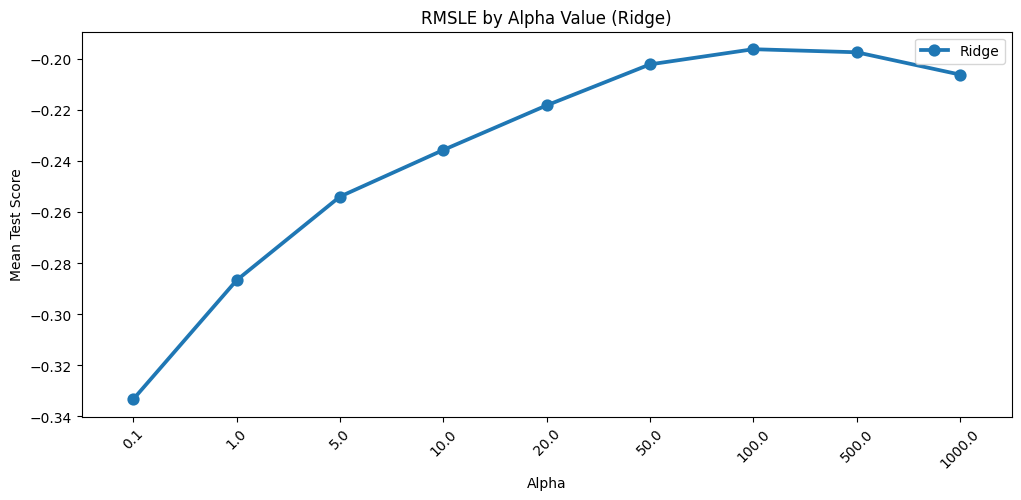

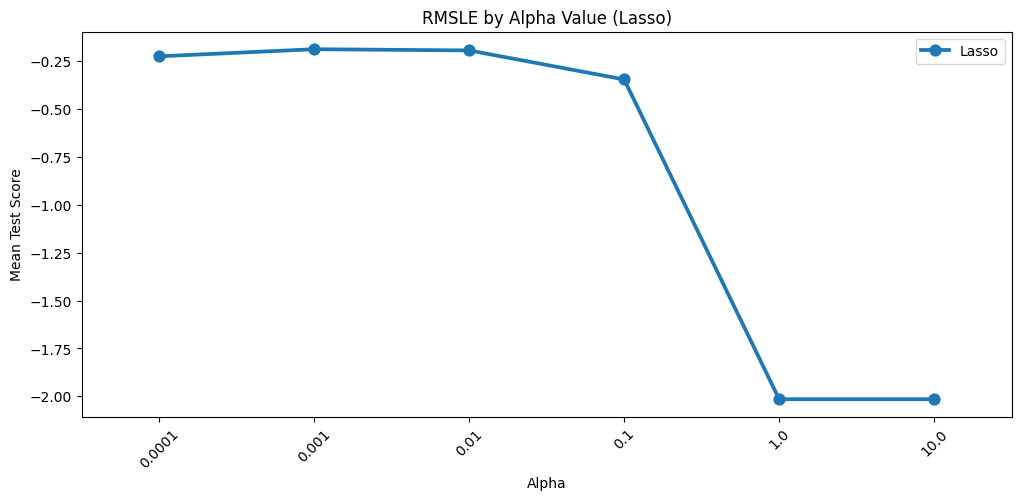

In [ ]:
# 결과 시각화 (Alpha 값에 따른 RMSLE 변화)
df_ridge = pd.DataFrame(grid_ridge.cv_results_)
df_lasso = pd.DataFrame(grid_lasso.cv_results_)

# Ridge 모델의 Alpha 값에 따른 RMSLE 변화 시각화
plt.figure(figsize=(12, 5))
ax1 = sns.pointplot(data=df_ridge, x="param_alpha", y="mean_test_score")
ax1.set_title("RMSLE by Alpha Value (Ridge)")
ax1.set_xlabel("Alpha")
ax1.set_ylabel("Mean Test Score")
plt.xticks(rotation=45)
plt.legend(["Ridge"])
plt.show()

# Lasso 모델의 Alpha 값에 따른 RMSLE 변화 시각화
plt.figure(figsize=(12, 5))
ax2 = sns.pointplot(data=df_lasso, x="param_alpha", y="mean_test_score")
ax2.set_title("RMSLE by Alpha Value (Lasso)")
ax2.set_xlabel("Alpha")
ax2.set_ylabel("Mean Test Score")
plt.xticks(rotation=45)
plt.legend(["Lasso"])
plt.show()


## 🎯 최종 성능

In [ ]:
# 성능 평가 결과 출력 (Baseline 모델)
print("🚀 [성능 평가] Baseline 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_base:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_base:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_base:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_base:.4f}")
print("="*60)

# 중간 성능 평가 (Linear Regression)
print("🚀 [중간 성능 평가] Linear Regression")
print(f"✅ RMSE (훈련 데이터): {rmse_train:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test:.4f}")
print("="*60)

# 성능 평가 결과 출력 (Ridge 모델)
print("🚀 [성능 평가] Ridge 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_ridge:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_ridge:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_ridge:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_ridge:.4f}")
print("="*60)

# 성능 평가 결과 출력 (Lasso 모델)
print("🚀 [성능 평가] Lasso 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_lasso:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_lasso:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_lasso:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_lasso:.4f}")

🚀 [성능 평가] Baseline 모델
✅ RMSE (훈련 데이터): 156.1296
✅ RMSE (테스트 데이터): 154.1943
✅ RMSLE (훈련 데이터): 1.4272
✅ RMSLE (테스트 데이터): 1.4317
🚀 [중간 성능 평가] Linear Regression
✅ RMSE (훈련 데이터): 74.0782
✅ RMSE (테스트 데이터): 134.2889
✅ RMSLE (훈련 데이터): 0.3751
✅ RMSLE (테스트 데이터): 0.6290
🚀 [성능 평가] Ridge 모델
✅ RMSE (훈련 데이터): 74.8986
✅ RMSE (테스트 데이터): 82.5379
✅ RMSLE (훈련 데이터): 0.3864
✅ RMSLE (테스트 데이터): 0.4384
🚀 [성능 평가] Lasso 모델
✅ RMSE (훈련 데이터): 76.1841
✅ RMSE (테스트 데이터): 81.3839
✅ RMSLE (훈련 데이터): 0.3966
✅ RMSLE (테스트 데이터): 0.4229


___
# **3.앙상블 모델 분석**

# ⭐ Random Forest 모델 학습

In [ ]:
# RandomizedSearchCV
param_grid_rf = {
    "n_estimators": [50, 100, 200],  # 트리 개수
    "max_depth": [10, 20, 30]  # 최대 깊이
}

rf_cv = RandomizedSearchCV(RandomForestRegressor(random_state=5),
                           param_distributions=param_grid_rf,
                           n_iter=4, cv=3, scoring="neg_mean_squared_error")

rf_cv.fit(X_train, y_train)

# 최적 하이퍼파라미터
best_params_rf = rf_cv.best_params_
best_n_estimators = best_params_rf["n_estimators"]
best_max_depth = best_params_rf["max_depth"]

# 최적 하이퍼파라미터 적용
rf_model = RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=5)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# RMSE 계산 (로그 해제 후 계산)
rmse_train_rf = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_rf)))
rmse_test_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_rf)))

# RMSLE 계산 (로그 변환된 상태에서 계산)
rmsle_train_rf = rmsle_log_transformed(y_train, y_train_pred_rf)
rmsle_test_rf = rmsle_log_transformed(y_test, y_test_pred_rf)

# 성능 평가 결과 출력 (Random Forest 모델)
print("🚀 [성능 평가] Random Forest 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_rf:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_rf:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_rf:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_rf:.4f}")


🚀 [성능 평가] Random Forest 모델
✅ RMSE (훈련 데이터): 18.2856
✅ RMSE (테스트 데이터): 42.0488
✅ RMSLE (훈련 데이터): 0.1200
✅ RMSLE (테스트 데이터): 0.3047


# ⭐ XGBoost 모델 학습

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import uniform
import numpy as np
from sklearn.metrics import mean_squared_error

# XGBoost 하이퍼파라미터 범위 설정
param_dist = {
    'n_estimators': [50, 100, 200],
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': [3, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# XGBoost 모델 설정
xgb_model = XGBRegressor(random_state=5)

# 랜덤 서치를 통해 최적 파라미터 찾기
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    scoring='neg_mean_squared_error',
    n_iter=50, cv=5, verbose=1, random_state=5, n_jobs=-1
)
random_search.fit(X_train, y_train)

# 최적 파라미터 출력
best_params = random_search.best_params_
print(f"Best parameters: {best_params}")

# 최적 모델로 예측 (훈련 데이터와 테스트 데이터)
xgb_best_model = random_search.best_estimator_
y_train_pred_xgb = xgb_best_model.predict(X_train)
y_test_pred_xgb = xgb_best_model.predict(X_test)

# RMSE 계산 (로그 해제 후 비교)
rmse_train_xgb = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_xgb)))
rmse_test_xgb = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_xgb)))

# RMSLE 계산 (로그 변환된 상태 유지)
rmsle_train_xgb = rmsle_log_transformed(y_train, y_train_pred_xgb)
rmsle_test_xgb = rmsle_log_transformed(y_test, y_test_pred_xgb)

# 성능 평가 결과 출력 (XGBoost 모델)
print("🚀 [성능 평가] XGBoost 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_xgb:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_xgb:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_xgb:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_xgb:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': 0.8899486110963666, 'learning_rate': 0.09131593656265129, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8773666934168969}
🚀 [성능 평가] XGBoost 모델
✅ RMSE (훈련 데이터): 28.6634
✅ RMSE (테스트 데이터): 37.7108
✅ RMSLE (훈련 데이터): 0.1820
✅ RMSLE (테스트 데이터): 0.2764


## 🎯 최종 성능

In [ ]:
# 성능 평가 결과 출력 (Random Forest 모델)
print("🚀 [성능 평가] Random Forest 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_rf:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_rf:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_rf:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_rf:.4f}")
print("="*60)

# 성능 평가 결과 출력 (XGBoost 모델)
print("🚀 [성능 평가] XGBoost 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_xgb:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_xgb:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_xgb:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_xgb:.4f}")

🚀 [성능 평가] Random Forest 모델
✅ RMSE (훈련 데이터): 18.2856
✅ RMSE (테스트 데이터): 42.0488
✅ RMSLE (훈련 데이터): 0.1200
✅ RMSLE (테스트 데이터): 0.3047
🚀 [성능 평가] XGBoost 모델
✅ RMSE (훈련 데이터): 28.6634
✅ RMSE (테스트 데이터): 37.7108
✅ RMSLE (훈련 데이터): 0.1820
✅ RMSLE (테스트 데이터): 0.2764


# 🚀 모든 모델 성능 평가 (RMSLE)

In [ ]:
# 성능 평가 결과 출력 (Baseline 모델)
print("🚀 [성능 평가] Baseline 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_base:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_base:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_base:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_base:.4f}")
print("="*60)

# 중간 성능 평가 (Linear Regression)
print("🚀 [중간 성능 평가] Linear Regression")
print(f"✅ RMSE (훈련 데이터): {rmse_train:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test:.4f}")
print("="*60)

# 성능 평가 결과 출력 (Ridge 모델)
print("🚀 [성능 평가] Ridge 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_ridge:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_ridge:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_ridge:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_ridge:.4f}")
print("="*60)

# 성능 평가 결과 출력 (Lasso 모델)
print("🚀 [성능 평가] Lasso 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_lasso:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_lasso:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_lasso:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_lasso:.4f}")
print("="*60)

# 성능 평가 결과 출력 (Random Forest 모델)
print("🚀 [성능 평가] Random Forest 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_rf:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_rf:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_rf:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_rf:.4f}")
print("="*60)

# 성능 평가 결과 출력 (XGBoost 모델)
print("🚀 [성능 평가] XGBoost 모델")
print(f"✅ RMSE (훈련 데이터): {rmse_train_xgb:.4f}")
print(f"✅ RMSE (테스트 데이터): {rmse_test_xgb:.4f}")
print(f"✅ RMSLE (훈련 데이터): {rmsle_train_xgb:.4f}")
print(f"✅ RMSLE (테스트 데이터): {rmsle_test_xgb:.4f}")

🚀 [성능 평가] Baseline 모델
✅ RMSE (훈련 데이터): 156.1296
✅ RMSE (테스트 데이터): 154.1943
✅ RMSLE (훈련 데이터): 1.4272
✅ RMSLE (테스트 데이터): 1.4317
🚀 [중간 성능 평가] Linear Regression
✅ RMSE (훈련 데이터): 74.0782
✅ RMSE (테스트 데이터): 134.2889
✅ RMSLE (훈련 데이터): 0.3751
✅ RMSLE (테스트 데이터): 0.6290
🚀 [성능 평가] Ridge 모델
✅ RMSE (훈련 데이터): 74.8986
✅ RMSE (테스트 데이터): 82.5379
✅ RMSLE (훈련 데이터): 0.3864
✅ RMSLE (테스트 데이터): 0.4384
🚀 [성능 평가] Lasso 모델
✅ RMSE (훈련 데이터): 76.1841
✅ RMSE (테스트 데이터): 81.3839
✅ RMSLE (훈련 데이터): 0.3966
✅ RMSLE (테스트 데이터): 0.4229
🚀 [성능 평가] Random Forest 모델
✅ RMSE (훈련 데이터): 18.2856
✅ RMSE (테스트 데이터): 42.0488
✅ RMSLE (훈련 데이터): 0.1200
✅ RMSLE (테스트 데이터): 0.3047
🚀 [성능 평가] XGBoost 모델
✅ RMSE (훈련 데이터): 28.6634
✅ RMSE (테스트 데이터): 37.7108
✅ RMSLE (훈련 데이터): 0.1820
✅ RMSLE (테스트 데이터): 0.2764


# 선형모델을 사용하여 실제 데이터 예측

In [ ]:
test_df.head()

,temp,atemp,humidity,windspeed,temp_diff,temp_ratio,weighted_temp,temp_std_diff,hour_sin,hour_cos,...,dayofweek_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4,year_2012
0,10.66,11.365,-0.421172,0.643676,-2.083028,-0.767665,-1.303264,-2.083028,0.000000,1.000000e+00,...,-0.900969,0,0,0,0,1,0,0,0,0
3,10.66,12.880,-0.421172,0.256912,-0.908676,0.150809,-1.248249,-0.908676,0.707107,7.071068e-01,...,-0.900969,0,0,0,0,1,0,0,0,0
4,10.66,12.880,-0.421172,0.256912,-0.908676,0.150809,-1.248249,-0.908676,0.866025,5.000000e-01,...,-0.900969,0,0,0,0,1,0,0,0,0
5,9.84,11.365,-0.213831,0.394104,-1.447405,-0.193492,-1.372744,-1.447405,0.965926,2.588190e-01,...,-0.900969,0,0,0,0,1,0,0,0,0
6,9.02,10.605,-0.213831,0.394104,-1.400896,-0.059450,-1.469822,-1.400896,1.000000,6.123234e-17,...,-0.900969,0,0,0,0,1,0,0,0,0


In [ ]:
X_train = train_df.drop(columns=["count", "temp", "weather_4","atemp"])  # feature 데이터
y_train = train_df["count"]  # target 데이터

X_test = test_df.drop(columns=["temp", "weather_4","atemp"])
# y_test = 예측 해야 하는 값

In [ ]:
# 다항 특성 변환
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [ ]:
# 베이스라인 모델 학습
baseline_model = LinearRegression()
baseline_model.fit(X_train_poly_scaled, y_train)

# 예측 수행
y_train_pred_base = baseline_model.predict(X_test_poly_scaled)

# 음수 예측값을 0으로 변환 (음수 방지)
y_train_pred_base = np.maximum(y_train_pred_base, 0)

In [ ]:
# 피처 엔지리어링 후 모델 학습
model = LinearRegression()
model.fit(X_train_poly_scaled, y_train)

# 예측 수행
test_predictions = model.predict(X_test_poly_scaled)

# 음수 값 방지
test_predictions = np.maximum(test_predictions, 0)

In [ ]:
# Ridge & Lasso 모델 학습
ridge_best.fit(X_train_poly_scaled, y_train)
lasso_best.fit(X_train_poly_scaled, y_train)

# 예측 수행
ridge_predictions = ridge_best.predict(X_test_poly_scaled)
lasso_predictions = lasso_best.predict(X_test_poly_scaled)

# 예측값 음수 방지
ridge_predictions = np.maximum(ridge_predictions, 0)
lasso_predictions = np.maximum(lasso_predictions, 0)


In [ ]:
# RandomForestRegressor 객체 생성 (최적 하이퍼파라미터 적용)
rf_best_model = RandomForestRegressor(**best_params_rf)  # 딕셔너리 언패킹

# 모델 학습
rf_best_model.fit(X_train_poly_scaled, y_train)

# 예측 수행
rf_predictions = rf_best_model.predict(X_test_poly_scaled)

# 예측값 음수 방지
rf_predictions = np.maximum(rf_predictions, 0)


In [ ]:
# XGBoost 모델 학습
xgb_best_model.fit(X_train_poly_scaled, y_train)

# 예측 수행
xgboost_predictions = xgb_best_model.predict(X_test_poly_scaled)

# 예측값 음수 방지
xgboost_predictions = np.maximum(xgboost_predictions, 0)


# train데이터의 count와 test데이터의 count 예측값 분포 비교

In [ ]:
print(train_df.shape)
print(test_df.shape)

(10886, 24)
(6493, 23)


In [ ]:
# 원본 데이터 다시 불러오기
original_test_df = pd.read_csv("test.csv")
original_train_df = pd.read_csv("train.csv")
print(original_train_df.shape)
print(original_test_df.shape)

(10886, 12)
(6493, 9)


In [ ]:
# 시계열 정렬 (날짜 기준)
original_train_df["datetime"] = pd.to_datetime(original_train_df["datetime"])
original_test_df["datetime"] = pd.to_datetime(original_test_df["datetime"])

original_test_df = original_test_df.sort_values(by="datetime").reset_index(drop=True)
original_train_df = original_train_df.sort_values(by="datetime").reset_index(drop=True)

In [ ]:
# 원본 train 데이터에 count_log 추가 (전처리된 train_df에서 가져옴)
original_train_df["count_log"] = train_df["count"]  # 로그 변환된 count 값 추가

# 원본 test 데이터에 count 추가 (예측값 추가)
original_test_df['baseline_count_log'] = np.log1p(test_predictions)  # 로그 변환
original_test_df['Linear_count_log'] = test_predictions
original_test_df["count_ridge_log"] = ridge_predictions
original_test_df["count_lasso_log"] = lasso_predictions
original_test_df["count_rf_log"] = rf_predictions
original_test_df["count_xgb_log"] = xgboost_predictions
original_test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,baseline_count_log,Linear_count_log,count_ridge_log,count_lasso_log,count_rf_log,count_xgb_log
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,1.192036,2.293782,2.408991,2.367298,2.578685,2.552055
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,0.904740,1.471290,1.651456,1.545375,1.416126,1.126037
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,1.000690,1.720158,1.905744,1.800984,1.349794,1.166854
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,1.163168,2.200055,2.370623,2.291371,1.730211,2.015746
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,1.342382,2.828150,2.976117,2.911665,3.604806,3.467451


In [ ]:
# 로그 해제한 값을 새로운 컬럼에 추가
original_test_df['baseline_count'] = y_train_pred_base # Baseline 모델 로그 해제
original_test_df['Linear_count'] = np.expm1(original_test_df['Linear_count_log'])
original_test_df['count_ridge'] = np.expm1(original_test_df['count_ridge_log'])
original_test_df['count_lasso'] = np.expm1(original_test_df['count_lasso_log'])
original_test_df['count_rf'] = np.expm1(original_test_df['count_rf_log'])
original_test_df['count_xgb'] = np.expm1(original_test_df['count_xgb_log'])

In [ ]:
# 예측 결과 상위 5개 확인
print("baseline 예측 결과:\n", y_train_pred_base)
print("feature engineering 후 예측 결과:\n", test_predictions)
print("Ridge 예측 결과:\n", ridge_predictions)
print("Lasso 예측 결과:\n", lasso_predictions)
print("Random Forest 예측 결과:\n", rf_predictions)
print("XGBoost 예측 결과:\n", xgboost_predictions)


baseline 예측 결과:
 [2.29378206 1.4712899  1.72015842 ... 3.91322084 3.6343507  5.4044069 ]
feature engineering 후 예측 결과:
 [2.29378206 1.4712899  1.72015842 ... 3.91322084 3.6343507  5.4044069 ]
Ridge 예측 결과:
 [2.40899143 1.65145571 1.90574352 ... 4.02308734 3.81698673 5.53360236]
Lasso 예측 결과:
 [2.36729816 1.54537478 1.80098406 ... 4.15835074 3.81892137 5.58025062]
Random Forest 예측 결과:
 [2.57868472 1.41612643 1.34979406 ... 5.70027435 4.27414846 5.12718307]
XGBoost 예측 결과:
 [2.5520554 1.1260372 1.1668543 ... 5.612512  4.614484  5.1048827]


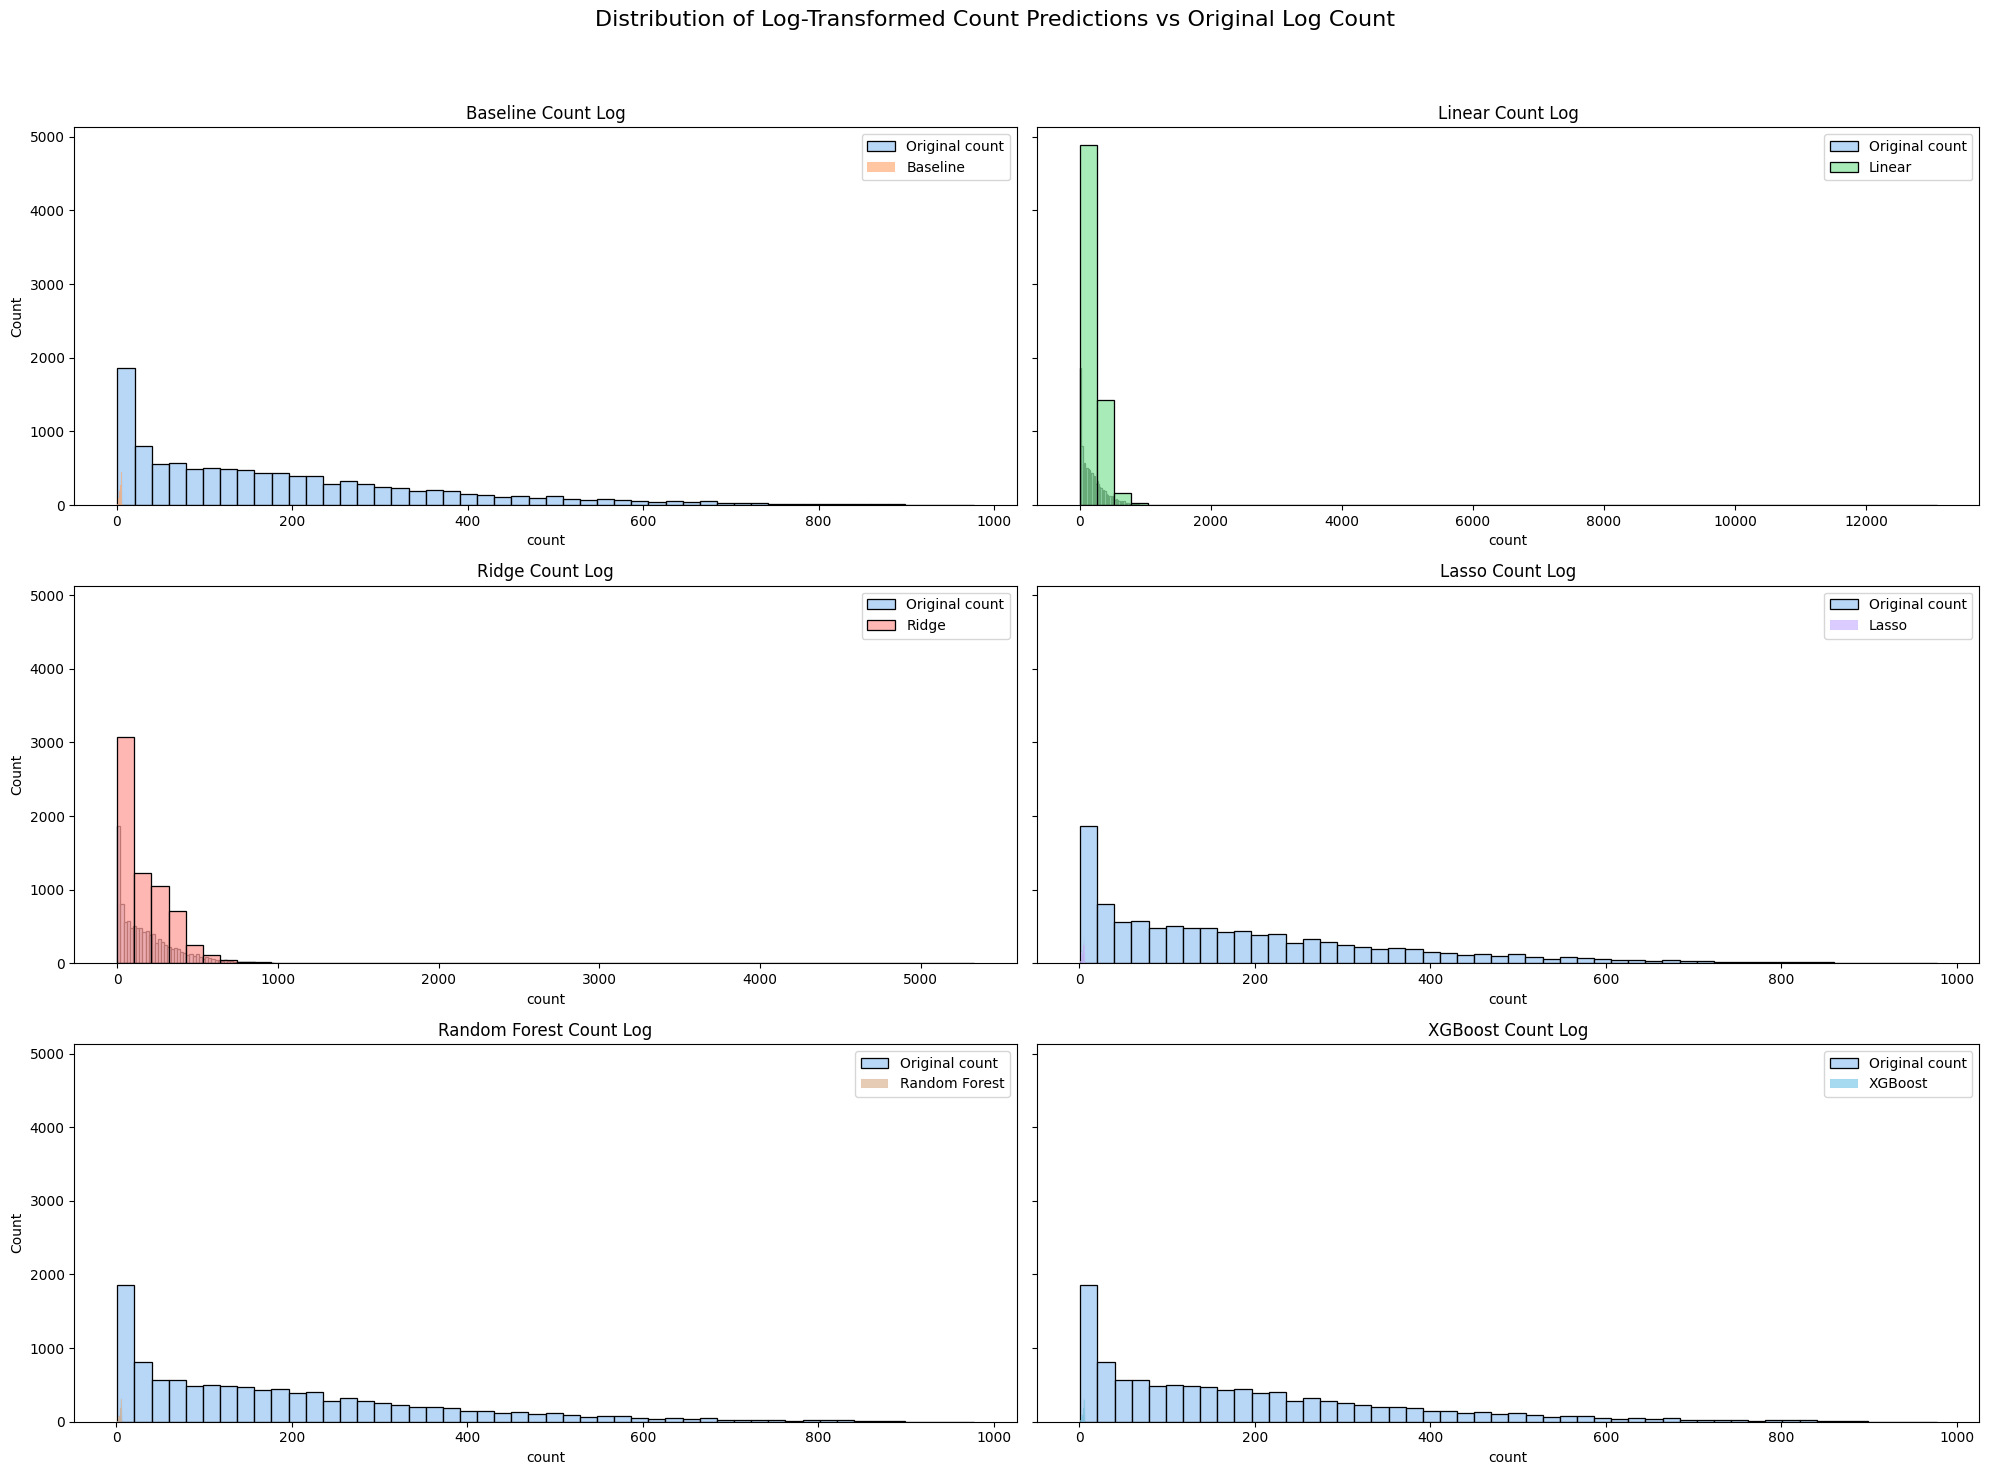

In [ ]:
# 📌 Seaborn 색상 팔레트 설정 (Pastel 톤)
palette = sns.color_palette("pastel", 6)

# 📌 서브플롯 설정 (6개)
fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharey=True)
fig.suptitle('Distribution of Log-Transformed Count Predictions vs Original Log Count', fontsize=16)

axes = axes.flatten()

# 📌 Baseline 모델
sns.histplot(original_train_df["count"], ax=axes[0], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["baseline_count"], ax=axes[0], label='Baseline', color=palette[1], bins=50)
axes[0].set_title('Baseline Count Log')
axes[0].legend()

# 📌 Linear Count Log
sns.histplot(original_train_df["count"], ax=axes[1], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["Linear_count"], ax=axes[1], label='Linear', color=palette[2], bins=50)
axes[1].set_title('Linear Count Log')
axes[1].legend()

# 📌 Ridge Count Log
sns.histplot(original_train_df["count"], ax=axes[2], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_ridge"], ax=axes[2], label='Ridge', color=palette[3], bins=50)
axes[2].set_title('Ridge Count Log')
axes[2].legend()

# 📌 Lasso Count Log
sns.histplot(original_train_df["count"], ax=axes[3], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_lasso_log"], ax=axes[3], label='Lasso', color=palette[4], bins=50)
axes[3].set_title('Lasso Count Log')
axes[3].legend()

# 📌 Random Forest Count Log
sns.histplot(original_train_df["count"], ax=axes[4], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_rf_log"], ax=axes[4], label='Random Forest', color=palette[5], bins=50)
axes[4].set_title('Random Forest Count Log')
axes[4].legend()

# 📌 XGBoost Count Log
sns.histplot(original_train_df["count"], ax=axes[5], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_xgb_log"], ax=axes[5], label='XGBoost', color="skyblue", bins=50)
axes[5].set_title('XGBoost Count Log')
axes[5].legend()

# 📌 그래프 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


- **base line은 스케일링을 하지않아서 크게 다름**

## 로그해제후 실제값 분포 비교

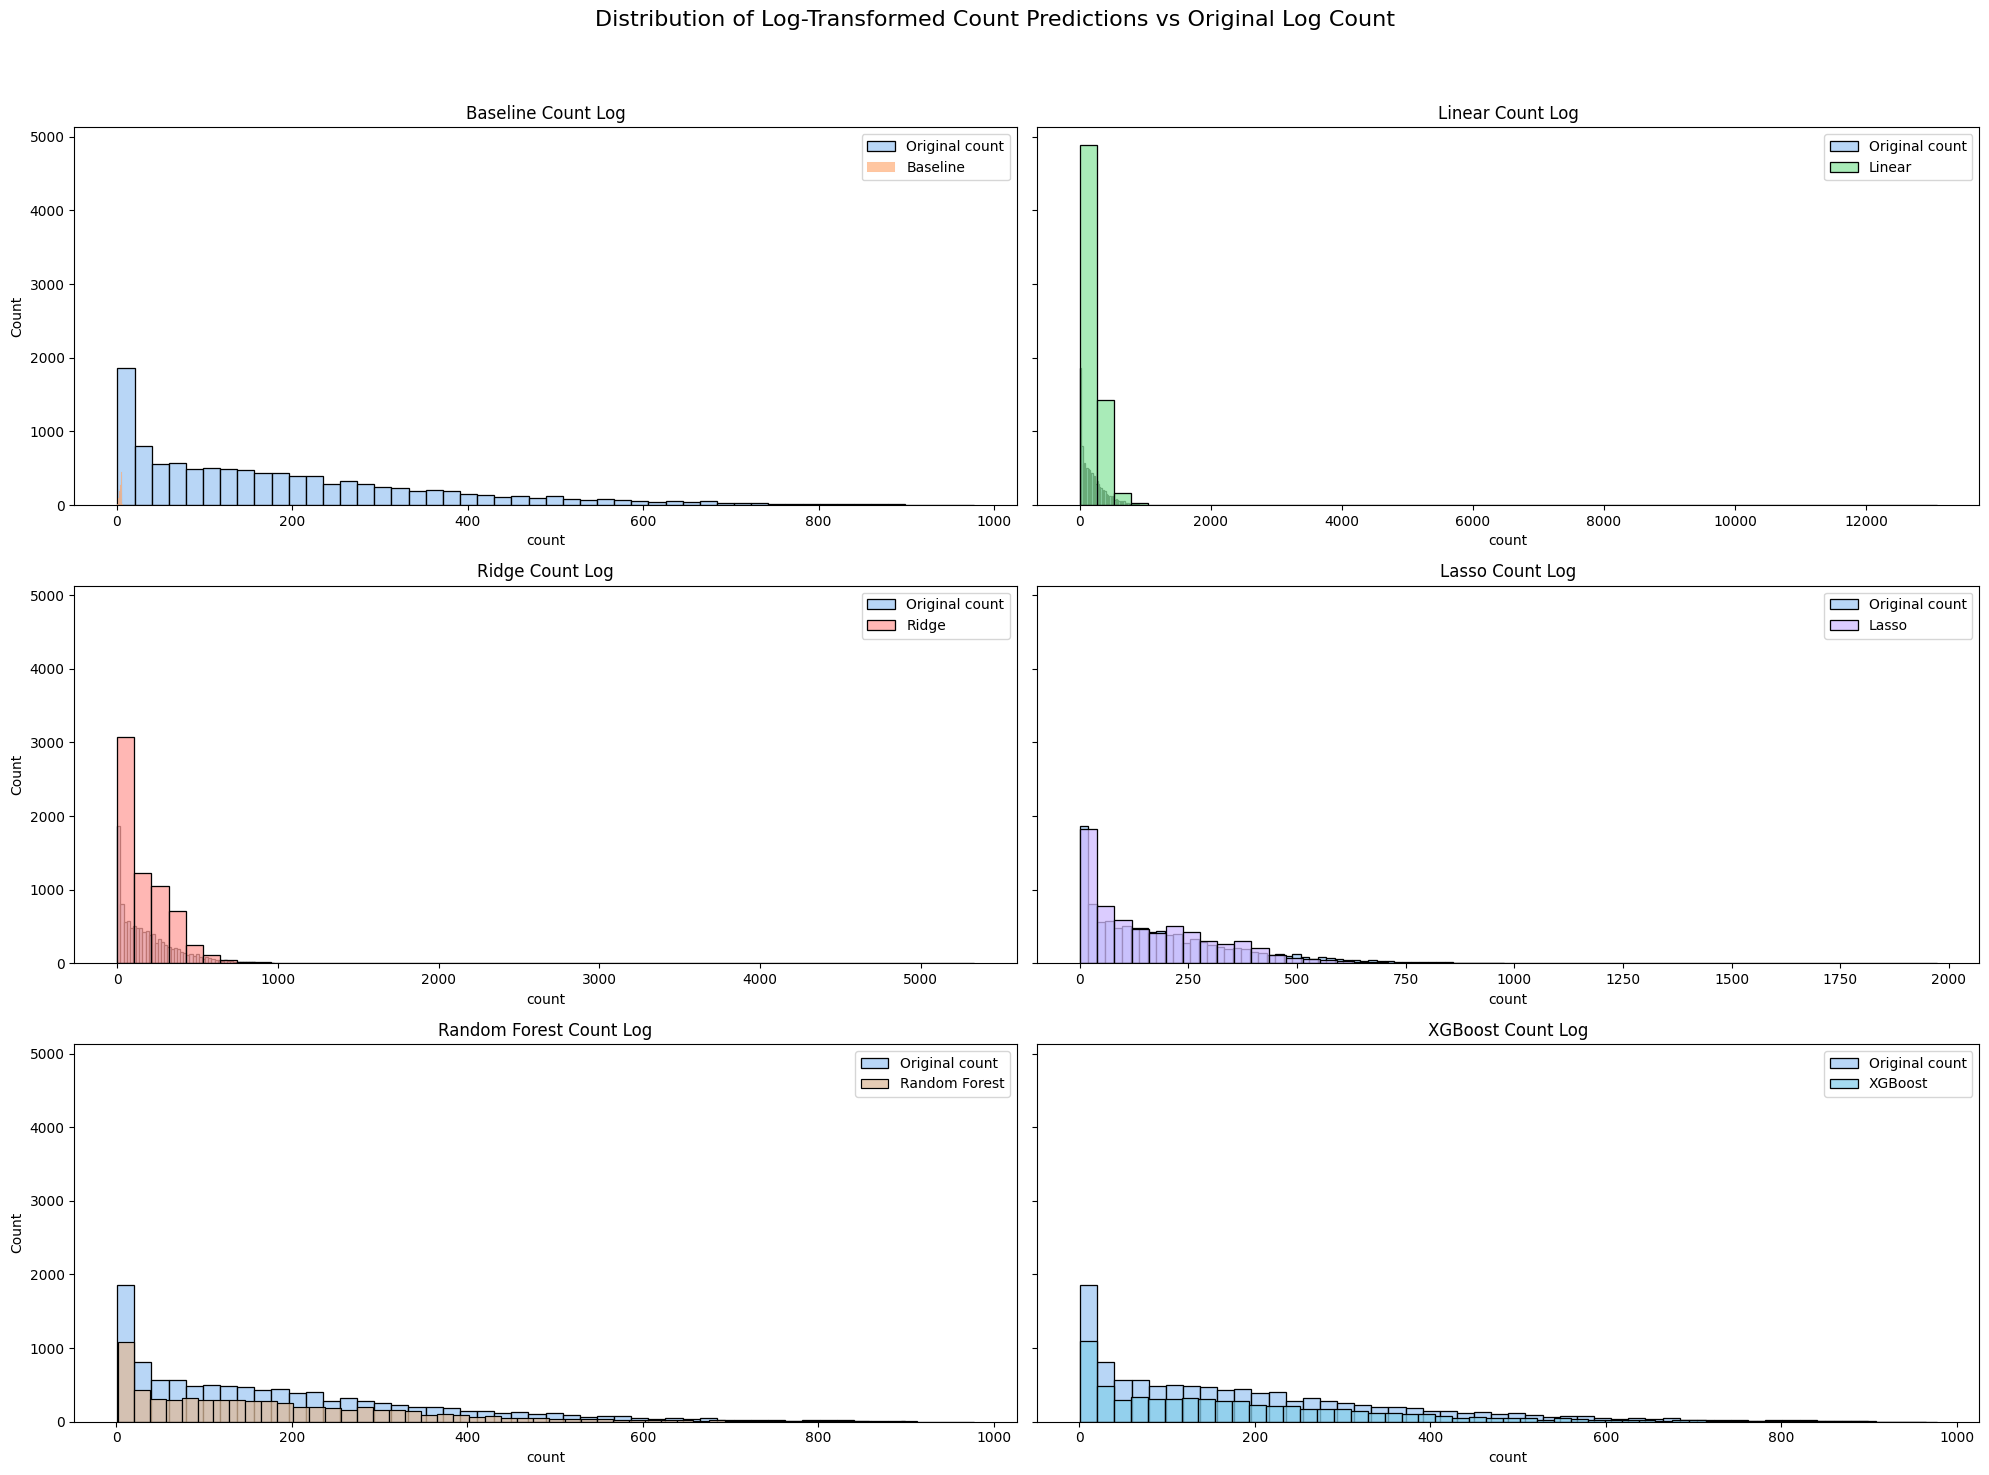

In [ ]:
# 📌 Seaborn 색상 팔레트 설정 (Pastel 톤)
palette = sns.color_palette("pastel", 6)

# 📌 서브플롯 설정 (6개)
fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharey=True)
fig.suptitle('Distribution of Log-Transformed Count Predictions vs Original Log Count', fontsize=16)

axes = axes.flatten()

# 📌 Baseline 모델
sns.histplot(original_train_df["count"], ax=axes[0], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["baseline_count"], ax=axes[0], label='Baseline', color=palette[1], bins=50)
axes[0].set_title('Baseline Count Log')
axes[0].legend()

# 📌 Linear Count Log
sns.histplot(original_train_df["count"], ax=axes[1], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["Linear_count"], ax=axes[1], label='Linear', color=palette[2], bins=50)
axes[1].set_title('Linear Count Log')
axes[1].legend()

# 📌 Ridge Count Log
sns.histplot(original_train_df["count"], ax=axes[2], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_ridge"], ax=axes[2], label='Ridge', color=palette[3], bins=50)
axes[2].set_title('Ridge Count Log')
axes[2].legend()

# 📌 Lasso Count Log
sns.histplot(original_train_df["count"], ax=axes[3], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_lasso"], ax=axes[3], label='Lasso', color=palette[4], bins=50)
axes[3].set_title('Lasso Count Log')
axes[3].legend()

# 📌 Random Forest Count Log
sns.histplot(original_train_df["count"], ax=axes[4], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_rf"], ax=axes[4], label='Random Forest', color=palette[5], bins=50)
axes[4].set_title('Random Forest Count Log')
axes[4].legend()

# 📌 XGBoost Count Log
sns.histplot(original_train_df["count"], ax=axes[5], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_xgb"], ax=axes[5], label='XGBoost', color="skyblue", bins=50)
axes[5].set_title('XGBoost Count Log')
axes[5].legend()

# 📌 그래프 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


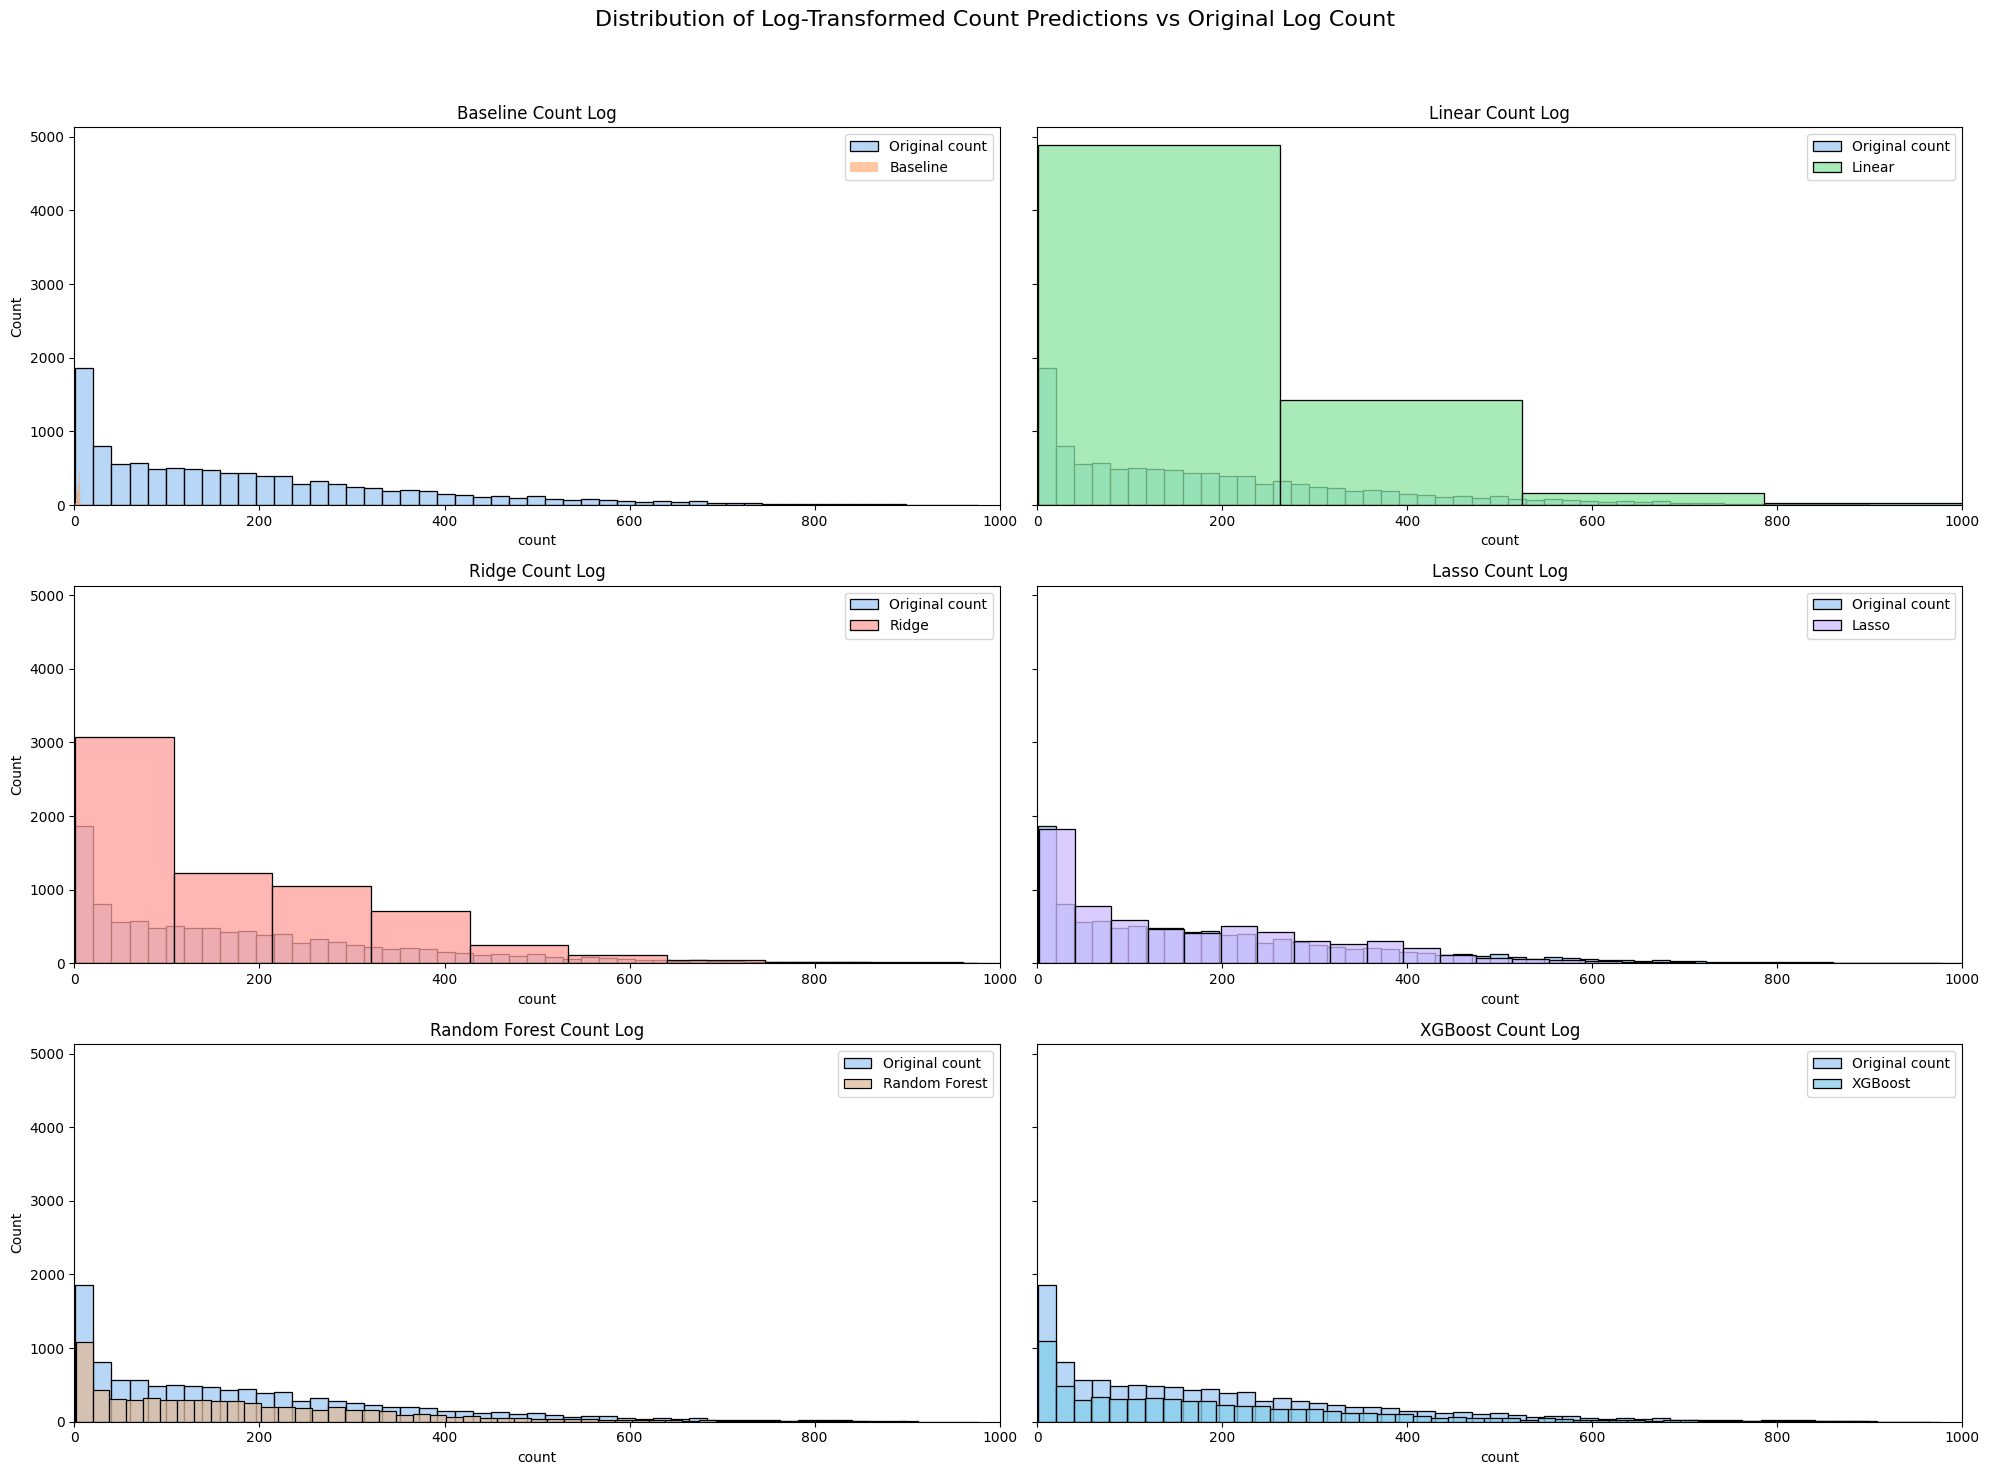

In [ ]:
# 📌 Seaborn 색상 팔레트 설정 (Pastel 톤)
palette = sns.color_palette("pastel", 6)

# 📌 서브플롯 설정 (6개)
fig, axes = plt.subplots(3, 2, figsize=(20, 15), sharey=True)

axes = axes.flatten()

fig.suptitle('Distribution of Log-Transformed Count Predictions vs Original Log Count', fontsize=16)

# 📌 Baseline 모델
sns.histplot(original_train_df["count"], ax=axes[0], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["baseline_count"], ax=axes[0], label='Baseline', color=palette[1], bins=50)
axes[0].set_title('Baseline Count Log')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# 📌 Linear Count Log
sns.histplot(original_train_df["count"], ax=axes[1], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["Linear_count"], ax=axes[1], label='Linear', color=palette[2], bins=50)
axes[1].set_title('Linear Count Log')
axes[1].legend()
axes[1].set_xlim(0, 1000)

# 📌 Ridge Count Log
sns.histplot(original_train_df["count"], ax=axes[2], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_ridge"], ax=axes[2], label='Ridge', color=palette[3], bins=50)
axes[2].set_title('Ridge Count Log')
axes[2].legend()
axes[2].set_xlim(0, 1000)

# 📌 Lasso Count Log
sns.histplot(original_train_df["count"], ax=axes[3], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_lasso"], ax=axes[3], label='Lasso', color=palette[4], bins=50)
axes[3].set_title('Lasso Count Log')
axes[3].legend()
axes[3].set_xlim(0, 1000)

# 📌 Random Forest Count Log
sns.histplot(original_train_df["count"], ax=axes[4], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_rf"], ax=axes[4], label='Random Forest', color=palette[5], bins=50)
axes[4].set_title('Random Forest Count Log')
axes[4].legend()
axes[4].set_xlim(0, 1000)

# 📌 XGBoost Count Log
sns.histplot(original_train_df["count"], ax=axes[5], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_xgb"], ax=axes[5], label='XGBoost', color="skyblue", bins=50)
axes[5].set_title('XGBoost Count Log')
axes[5].legend()
axes[5].set_xlim(0, 1000)

# 📌 그래프 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


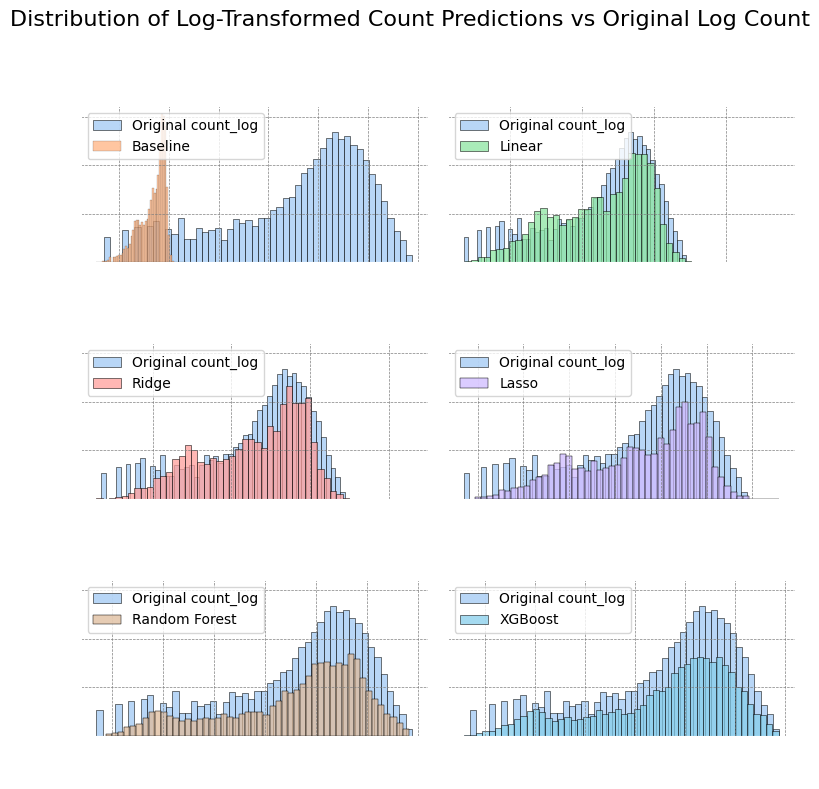

In [ ]:
# 📌 Seaborn 색상 팔레트 설정 (Pastel 톤)
palette = sns.color_palette("pastel", 6)

# 📌 서브플롯 설정 (6개)
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharey=True)

axes = axes.flatten()
# 📌 공통 스타일 설정 (배경 투명, 축/글씨 흰색)
for ax in axes:
    ax.set_facecolor('#ffffff')  # 그래프 내부 그리드 배경색 설정 (어두운 회색)
    ax.grid(color='gray', linestyle='--', linewidth=0.5)  # 그리드 선 스타일
    ax.tick_params(axis='both', colors='white')  # 축 눈금 색상
    ax.spines['bottom'].set_color('white')  # 아래쪽 테두리
    ax.spines['top'].set_color('white')     # 위쪽 테두리
    ax.spines['left'].set_color('white')    # 왼쪽 테두리
    ax.spines['right'].set_color('white')   # 오른쪽 테두리
    ax.title.set_color('white')             # 제목 색상
    ax.yaxis.label.set_color('white')       # y축 라벨 색상
    ax.xaxis.label.set_color('white')       # x축 라벨 색상

fig.suptitle('Distribution of Log-Transformed Count Predictions vs Original Log Count', fontsize=16)

# 📌 Baseline 모델
sns.histplot(original_train_df["count_log"], ax=axes[0], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["baseline_count_log"], ax=axes[0], label='Baseline', color=palette[1], bins=50)
axes[0].set_title('Baseline Count Log')
axes[0].legend()

# 📌 Linear Count Log
sns.histplot(original_train_df["count_log"], ax=axes[1], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["Linear_count_log"], ax=axes[1], label='Linear', color=palette[2], bins=50)
axes[1].set_title('Linear Count Log')
axes[1].legend()

# 📌 Ridge Count Log
sns.histplot(original_train_df["count_log"], ax=axes[2], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["count_ridge_log"], ax=axes[2], label='Ridge', color=palette[3], bins=50)
axes[2].set_title('Ridge Count Log')
axes[2].legend()

# 📌 Lasso Count Log
sns.histplot(original_train_df["count_log"], ax=axes[3], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["count_lasso_log"], ax=axes[3], label='Lasso', color=palette[4], bins=50)
axes[3].set_title('Lasso Count Log')
axes[3].legend()

# 📌 Random Forest Count Log
sns.histplot(original_train_df["count_log"], ax=axes[4], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["count_rf_log"], ax=axes[4], label='Random Forest', color=palette[5], bins=50)
axes[4].set_title('Random Forest Count Log')
axes[4].legend()

# 📌 XGBoost Count Log
sns.histplot(original_train_df["count_log"], ax=axes[5], label='Original count_log', color=palette[0], bins=50)
sns.histplot(original_test_df["count_xgb_log"], ax=axes[5], label='XGBoost', color="skyblue", bins=50)
axes[5].set_title('XGBoost Count Log')
axes[5].legend()

# 📌 그래프 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.patch.set_alpha(0)  # 전체 그림 배경 투명
plt.show()


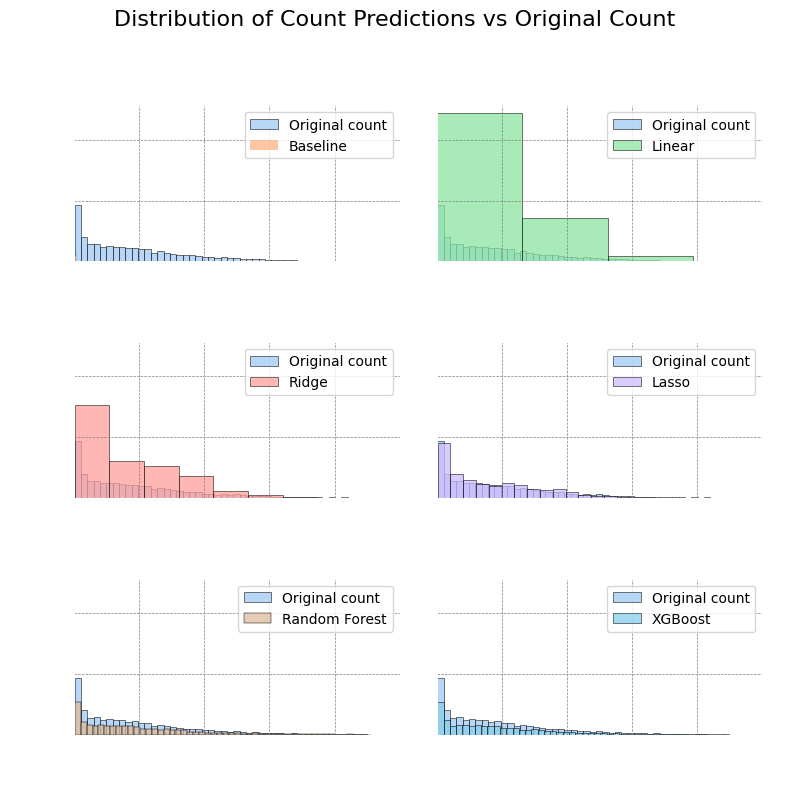

In [ ]:
# 📌 Seaborn 색상 팔레트 설정 (Pastel 톤)
palette = sns.color_palette("pastel", 6)

# 📌 서브플롯 설정 (6개)
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharey=True)

axes = axes.flatten()
# 📌 공통 스타일 설정 (배경 투명, 축/글씨 흰색)
for ax in axes:
    ax.set_facecolor('#ffffff')  # 그래프 내부 그리드 배경색 설정 (어두운 회색)
    ax.grid(color='gray', linestyle='--', linewidth=0.5)  # 그리드 선 스타일
    ax.tick_params(axis='both', colors='white')  # 축 눈금 색상
    ax.spines['bottom'].set_color('white')  # 아래쪽 테두리
    ax.spines['top'].set_color('white')     # 위쪽 테두리
    ax.spines['left'].set_color('white')    # 왼쪽 테두리
    ax.spines['right'].set_color('white')   # 오른쪽 테두리
    ax.title.set_color('white')             # 제목 색상
    ax.yaxis.label.set_color('white')       # y축 라벨 색상
    ax.xaxis.label.set_color('white')       # x축 라벨 색상

fig.suptitle('Distribution of Count Predictions vs Original Count', fontsize=16)

# 📌 Baseline 모델
sns.histplot(original_train_df["count"], ax=axes[0], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["baseline_count"], ax=axes[0], label='Baseline', color=palette[1], bins=50)
axes[0].set_title('Baseline Count')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# 📌 Linear Count
sns.histplot(original_train_df["count"], ax=axes[1], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["Linear_count"], ax=axes[1], label='Linear', color=palette[2], bins=50)
axes[1].set_title('Linear Count')
axes[1].legend()
axes[1].set_xlim(0, 1000)

# 📌 Ridge Count
sns.histplot(original_train_df["count"], ax=axes[2], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_ridge"], ax=axes[2], label='Ridge', color=palette[3], bins=50)
axes[2].set_title('Ridge Count')
axes[2].legend()
axes[2].set_xlim(0, 1000)

# 📌 Lasso Count
sns.histplot(original_train_df["count"], ax=axes[3], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_lasso"], ax=axes[3], label='Lasso', color=palette[4], bins=50)
axes[3].set_title('Lasso Count')
axes[3].legend()
axes[3].set_xlim(0, 1000)

# 📌 Random Forest Count
sns.histplot(original_train_df["count"], ax=axes[4], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_rf"], ax=axes[4], label='Random Forest', color=palette[5], bins=50)
axes[4].set_title('Random Forest Count')
axes[4].legend()
axes[4].set_xlim(0, 1000)

# 📌 XGBoost Count
sns.histplot(original_train_df["count"], ax=axes[5], label='Original count', color=palette[0], bins=50)
sns.histplot(original_test_df["count_xgb"], ax=axes[5], label='XGBoost', color="skyblue", bins=50)
axes[5].set_title('XGBoost Count')
axes[5].legend()
axes[5].set_xlim(0, 1000)

# 📌 그래프 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.patch.set_alpha(0)  # 전체 그림 배경 투명
plt.show()
